## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import corner

import jax
import jax.numpy as jnp
key = jax.random.key(57)

import numpyro
num_chains = 4
numpyro.set_host_device_count(num_chains)

import arviz as az

import scipy.optimize as opt

jax.local_device_count()

1

## Data Visualization

In [2]:
# Load from CSV file into a dataframe
df = pd.read_csv('dataverse_files/1-Fragment_C_Hole_Measurements.csv')

In [3]:
# inspect data
df.describe()

,Section ID,Hole,Inter-hole Distance,Mean(X),Mean(Y)
count,81.000000,81.000000,74.000000,81.000000,81.000000
mean,2.765432,41.000000,1.365023,61.455655,67.344916
std,1.690204,23.526581,0.127190,29.778150,9.901871
min,0.000000,1.000000,1.051062,15.599310,58.336800
25%,1.000000,21.000000,1.264972,35.109380,59.594790
50%,3.000000,41.000000,1.389709,59.726390,62.990970
75%,3.000000,61.000000,1.447388,86.902780,72.885420
max,7.000000,81.000000,1.651650,113.640280,92.596530


In [4]:
# different ways to view the dataframe to inspect data
df.head()
df

,Section ID,Hole,Inter-hole Distance,Mean(X),Mean(Y)
0,0,1,NaN,15.59931,92.59653
1,1,2,NaN,16.44167,91.50069
2,1,3,1.440694,17.30764,90.34931
3,1,4,1.456973,18.15278,89.16250
4,1,5,1.299821,18.96528,88.14792
...,...,...,...,...,...
76,7,77,1.259985,108.69444,63.42778
77,7,78,1.430105,110.05486,63.86875
78,7,79,1.179606,111.14583,64.31736
79,7,80,1.428043,112.48021,64.82604


In [5]:
# checking for None values
df.all()

Section ID             False
Hole                    True
Inter-hole Distance     True
Mean(X)                 True
Mean(Y)                 True
dtype: bool

In [6]:
df["Section ID"].value_counts()

Section ID
3    37
1    22
2     9
7     6
5     3
6     2
0     1
4     1
Name: count, dtype: int64

Text(0.5, 1.0, 'Scatter Plot of Antikythera Mechanism Remained Part')

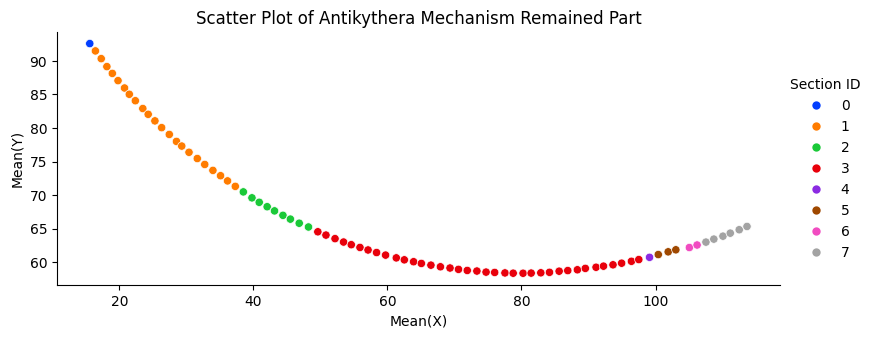

In [7]:
# visualizing the data using seaborn's method for scatterplot
plot = sns.relplot(data=df,x="Mean(X)", y="Mean(Y)", hue="Section ID", palette ="bright", height = 8, aspect = 1)

# Set equal scaling for the x and y axes
plt.gca().set_aspect('equal')

# Rotate the plot by flipping the axes to mimic image in the task
#plt.gca().invert_yaxis()

plt.xlabel('Mean(X)')
plt.ylabel('Mean(Y)')
plt.title('Scatter Plot of Antikythera Mechanism Remained Part')

# numeration
#for i in range(df.shape[0]):
#    plt.text(df['Mean(X)'][i], df['Mean(Y)'][i], df['Hole'][i], fontsize=5, ha='right')

# matplotlib version
# plt.figure(figsize=(8,6))
# plt.scatter(df["Mean(X)"], df["Mean(Y)"], c=df['Section ID'], cmap="Pastel1")
# plt.axis('equal') 
# plt.legend(labels = df['Section ID'])
# plt.title("Calendar ring visualization")

In [8]:
data = (df["Mean(X)"], df["Mean(Y)"])

In [9]:
# getting segments ID for each pt
seg_cords_0 = df[df["Section ID"] == 0]["Hole"]
seg_cords_1 = df[df["Section ID"] == 1]["Hole"]
seg_cords_2 = df[df["Section ID"] == 2]["Hole"]
seg_cords_3 = df[df["Section ID"] == 3]["Hole"]
seg_cords_4 = df[df["Section ID"] == 4]["Hole"]
seg_cords_5 = df[df["Section ID"] == 5]["Hole"]
seg_cords_6 = df[df["Section ID"] == 6]["Hole"]
seg_cords_7 = df[df["Section ID"] == 7]["Hole"]

for i in range(3):
    if i in seg_cords_0:
        print("Section Id is 0")
    elif i in seg_cords_1:
        print("Section Id is 1")

Section Id is 0
Section Id is 1
Section Id is 1


## Function (outputting holes based on params)

N - number of holes

r - radius of circle

s - contiguous arc sections

r_0j = (x_0j,y_0j) - circle-centres of the section arcs are at s closely bunched but unknown locations

α_j - the angular position of the first hole of the full circle 
            (we expect these α_j values to be very similar), 0<j<(s-1)


angular position of the ith hole in the jth section with respect to its arc-centre is therefore:
           φ_ij = 2π(i−1)/N + α_j.


parameter vector: a = (N,r,{(x_0j,y_0j)},{α_j},C)

C represents a parameterised characterisation of random positional errors

In [10]:
# defining the model which outputs 81 holes locations based on segments' inputs

def holes_locations(N, r, x_00, x_01, x_02, x_03, x_04, x_05, x_06, x_07,
                    y_00, y_01, y_02, y_03, y_04, y_05, y_06, y_07, 
                    alpha_0, alpha_1, alpha_2, alpha_3, alpha_4, alpha_5, alpha_6, alpha_7, 
                    s=8, num_holes=81):
    """
    Calculate the intended positions of 81 holes based on parameters.

    This function determines the positions of holes distributed across several segments. 
    Each segment has its own center and angular offset.

    Parameters:
    - N (int): Total number of holes used for angle calculations.
    - r (float): Radius for calculating the distance of holes from their arc-center.
    - x_00 to x_07 (float): X-coordinates of the center for each segment.
    - y_00 to y_07 (float): Y-coordinates of the center for each segment.
    - alpha_0 to alpha_7 (float): Angular offsets for each segment, influencing hole spacing in radians.
    - s (int, optional): The number of segments to consider. Default is 8.
    - num_holes (int, optional): Total number of holes to place, default is 81.

    Returns:
        jax.numpy.ndarray: An array of shape (81, 2) containing the calculated x and y coordinates of the hole positions.
    """
    
    intended_positions = jnp.zeros((num_holes, 2))

    for i in range(num_holes):
        if i in seg_cords_0:   
            phi_ij = 2 * jnp.pi * (i - 1) / N + alpha_0 # angular position of the ith hole in the jth section with respect to its arc-centre
            r_ij = jnp.array([jnp.cos(phi_ij), jnp.sin(phi_ij)]) * r  #distance from jth centre 
            intended_pos_ij = r_ij + jnp.array([x_00, y_00]) # Intended hole position
            intended_positions = intended_positions.at[i].set(intended_pos_ij)
        
        elif i in seg_cords_1:   
            phi_ij = 2 * jnp.pi * (i - 1) / N + alpha_1 # angular position of the ith hole in the jth section with respect to its arc-centre
            r_ij = jnp.array([jnp.cos(phi_ij), jnp.sin(phi_ij)]) * r  #distance from jth centre 
            intended_pos_ij = r_ij + jnp.array([x_01, y_01]) # Intended hole position
            intended_positions = intended_positions.at[i].set(intended_pos_ij)

        elif i in seg_cords_2:   
            phi_ij = 2 * jnp.pi * (i - 1) / N + alpha_2 # angular position of the ith hole in the jth section with respect to its arc-centre
            r_ij = jnp.array([jnp.cos(phi_ij), jnp.sin(phi_ij)]) * r  #distance from jth centre 
            intended_pos_ij = r_ij + jnp.array([x_02, y_02]) # Intended hole position
            intended_positions = intended_positions.at[i].set(intended_pos_ij)

        elif i in seg_cords_3:   
            phi_ij = 2 * jnp.pi * (i - 1) / N + alpha_3 # angular position of the ith hole in the jth section with respect to its arc-centre
            r_ij = jnp.array([jnp.cos(phi_ij), jnp.sin(phi_ij)]) * r  #distance from jth centre 
            intended_pos_ij = r_ij + jnp.array([x_03, y_03]) # Intended hole position
            intended_positions = intended_positions.at[i].set(intended_pos_ij)

        elif i in seg_cords_4:   
            phi_ij = 2 * jnp.pi * (i - 1) / N + alpha_4 # angular position of the ith hole in the jth section with respect to its arc-centre
            r_ij = jnp.array([jnp.cos(phi_ij), jnp.sin(phi_ij)]) * r  #distance from jth centre 
            intended_pos_ij = r_ij + jnp.array([x_04, y_04]) # Intended hole position
            intended_positions = intended_positions.at[i].set(intended_pos_ij)

        elif i in seg_cords_5:   
            phi_ij = 2 * jnp.pi * (i - 1) / N + alpha_5 # angular position of the ith hole in the jth section with respect to its arc-centre
            r_ij = jnp.array([jnp.cos(phi_ij), jnp.sin(phi_ij)]) * r  #distance from jth centre 
            intended_pos_ij = r_ij + jnp.array([x_05, y_05]) # Intended hole position
            intended_positions = intended_positions.at[i].set(intended_pos_ij)

        elif i in seg_cords_6:   
            phi_ij = 2 * jnp.pi * (i - 1) / N + alpha_6 # angular position of the ith hole in the jth section with respect to its arc-centre
            r_ij = jnp.array([jnp.cos(phi_ij), jnp.sin(phi_ij)]) * r  #distance from jth centre 
            intended_pos_ij = r_ij + jnp.array([x_06, y_06]) # Intended hole position
            intended_positions = intended_positions.at[i].set(intended_pos_ij)

        elif i in seg_cords_7:   
            phi_ij = 2 * jnp.pi * (i - 1) / N + alpha_7 # angular position of the ith hole in the jth section with respect to its arc-centre
            r_ij = jnp.array([jnp.cos(phi_ij), jnp.sin(phi_ij)]) * r  #distance from jth centre 
            intended_pos_ij = r_ij + jnp.array([x_07, y_07]) # Intended hole position
            intended_positions = intended_positions.at[i].set(intended_pos_ij)

    return intended_positions

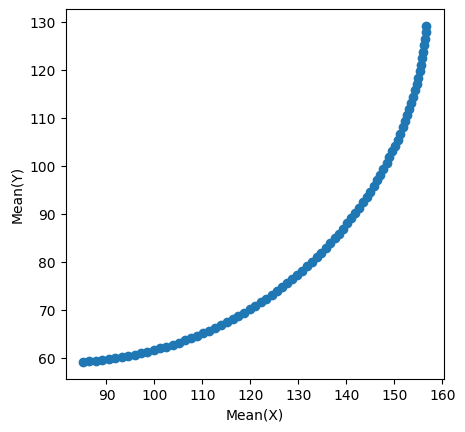

In [11]:
# mock data production
mock_data_circle = holes_locations(N=355, r=77, 
                            x_00=80, x_01=80, x_02=80, x_03=80, x_04=80, x_05=80, x_06=80, x_07=80,
                            y_00=136, y_01=136, y_02=136, y_03=136, y_04=136, y_05=136, y_06=136, y_07=136, 
                            alpha_0=-146, alpha_1=-146, alpha_2=-146, alpha_3=-146, alpha_4=-146, alpha_5=-146, alpha_6=-146, alpha_7=-146)
plt.scatter(mock_data_circle[:,0], mock_data_circle[:,1])
plt.xlabel("Mean(X)")
plt.ylabel("Mean(Y)")
# Set equal scaling for the x and y axes
plt.gca().set_aspect('equal')

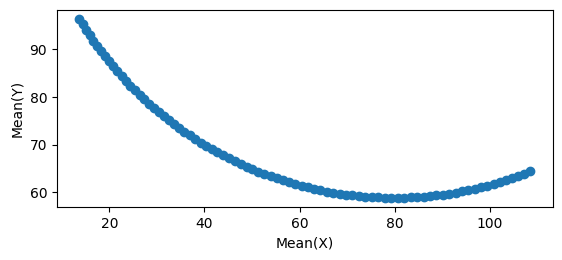

In [12]:
# mock nuanced data production
mock_data_test = holes_locations(N=355, r=77, 
                            x_00=79.9, x_01=79.9, x_02=79.9, x_03=79.9, x_04=79.9, x_05=79.9, x_06=79.9, x_07=79.9,
                            y_00=135.8, y_01=135.8, y_02=135.8, y_03=135.8, y_04=135.8, y_05=135.8, y_06=135.8, y_07=135.8, 
                            alpha_0=-184.8, alpha_1=-184.8, alpha_2=-184.8, alpha_3=-184.8, alpha_4=-184.8, alpha_5=-184.8, alpha_6=-184.8, alpha_7=-184.8)
plt.scatter(mock_data_test[:,0], mock_data_test[:,1])
plt.xlabel("Mean(X)")
plt.ylabel("Mean(Y)")
plt.gca().set_aspect('equal') # Set equal scaling for the x and y axes

Compare data to model output (verifying model works correctly)

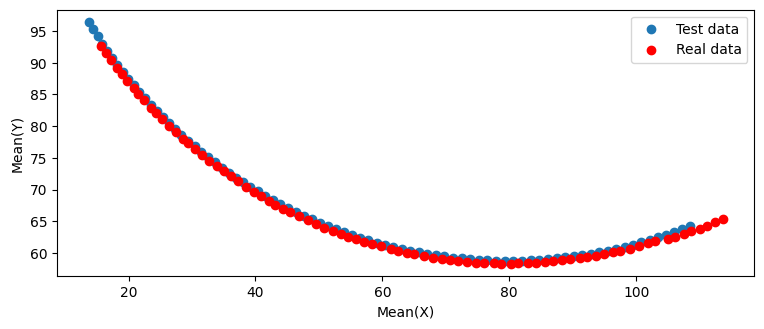

In [13]:
plt.figure(figsize=(9,6))
plt.scatter(mock_data_test[:,0], mock_data_test[:,1], label="Test data")
plt.scatter(df["Mean(X)"], df["Mean(Y)"], c='r', label="Real data")
plt.xlabel("Mean(X)")
plt.ylabel("Mean(Y)")
plt.legend()
plt.gca().set_aspect('equal') # Set equal scaling for the x and y axes


## Model w/ 2-dimensional isotropic Gaussian covariance

In [14]:
# model with a 2-dimensional isotropic Gaussian distribution with standard deviation sigma
def model(data):
    s = 8 # Number of sections
    num_points = 81 # Number of holes
    
    # Defining priors
    N = numpyro.sample("N", numpyro.distributions.Uniform(340., 370.)) 
    r = numpyro.sample("r", numpyro.distributions.Uniform(50., 100.))
    sigma = numpyro.sample("sigma", numpyro.distributions.Uniform(0., 5.))

    cov = jnp.array([[sigma**2, 0], [0, sigma**2]])

    alpha_j = numpyro.sample("alpha_j", numpyro.distributions.Uniform(-180., 180.).expand([s])) # angular position of the first hole
    x_0j = numpyro.sample("x_0j", numpyro.distributions.Uniform(0., 150.).expand([s]))
    y_0j = numpyro.sample("y_0j", numpyro.distributions.Uniform(50., 200.).expand([s]))

    model = numpyro.deterministic("model", holes_locations(N, r, 
                            x_0j[0], x_0j[1], x_0j[2], x_0j[3], x_0j[4], x_0j[5], x_0j[6], x_0j[7],
                            y_0j[0], y_0j[1], y_0j[2], y_0j[3], y_0j[4], y_0j[5], y_0j[6], y_0j[7], 
                            alpha_j[0], alpha_j[1], alpha_j[2], alpha_j[3], alpha_j[4], alpha_j[5], alpha_j[6], alpha_j[7]))
        
    with numpyro.plate("data", num_points):
        numpyro.sample("obs", numpyro.distributions.MultivariateNormal(model, covariance_matrix = cov), obs=data)

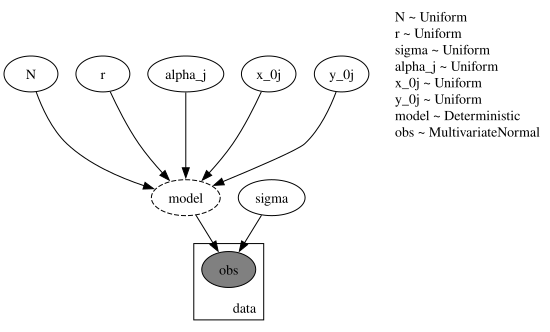

In [15]:
data_points = jnp.array(df[["Mean(X)", "Mean(Y)"]].to_numpy())

numpyro.render_model(
    model=model,
    model_kwargs={"data": data_points},
    render_distributions=True,
    render_params=True,
)

### Prior Predictive Distribution

dict_keys(['N', 'alpha_j', 'model', 'obs', 'r', 'sigma', 'x_0j', 'y_0j'])
[[[ 67.9096   161.16281 ]
  [ 69.57749   93.215675]
  [ 69.08608   92.27919 ]
  ...
  [186.99142   85.81596 ]
  [186.55412   86.88985 ]
  [186.43655   87.89061 ]]

 [[ 31.03697  208.95512 ]
  [137.43922   58.58093 ]
  [143.01614   51.234867]
  ...
  [-18.603064  47.84722 ]
  [-21.235947  49.722748]
  [-16.925453  45.226345]]

 [[141.00523  151.56357 ]
  [  9.948298  44.502003]
  [ 16.068533  49.87797 ]
  ...
  [232.69334  148.89856 ]
  [234.4843   149.58307 ]
  [229.75603  157.3174  ]]

 ...

 [[138.40607   77.65428 ]
  [-25.548513 176.13622 ]
  [-28.79236  170.70448 ]
  ...
  [ 66.40767  116.02805 ]
  [ 64.813736 116.366875]
  [ 67.65398  115.33383 ]]

 [[-16.566301 124.26076 ]
  [ 97.36068  261.14252 ]
  [ 96.85735  260.0724  ]
  ...
  [137.41866  128.3831  ]
  [135.51346  129.61455 ]
  [134.69287  129.91193 ]]

 [[ 12.054302 170.34906 ]
  [-52.55257   80.99026 ]
  [-42.68818   66.68804 ]
  ...
  [ 78.907906 -2

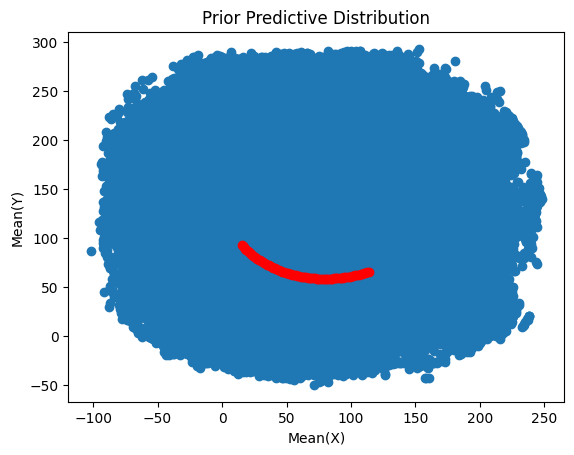

In [16]:
# Create a predictive object
num_samples = 1000
predictive = numpyro.infer.Predictive(model, num_samples=1000)

# Generate random samples from the prior
prior_samples = predictive(rng_key=jax.random.PRNGKey(0), data=None)
print(prior_samples.keys())

# Visualize prior predictions
observations = prior_samples['obs']
print(observations)

# Visualizing prior predictions
plt.scatter(observations[:,:,0],observations[:,:,1])
plt.scatter(df["Mean(X)"], df["Mean(Y)"], c='r')
plt.xlabel("Mean(X)")
plt.ylabel("Mean(Y)")
plt.title("Prior Predictive Distribution")
plt.show()

### Inference (MCMC)

In [17]:
data_points = jnp.array(df[["Mean(X)", "Mean(Y)"]].to_numpy())

# MCMC Setup
nuts_kernel = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(nuts_kernel, num_warmup=5000, num_samples=10000)
key, subkey = jax.random.split(key) 
mcmc.run(subkey, data = data_points)

# Summarize the MCMC results
mcmc.print_summary()

sample: 100%|██████████| 15000/15000 [06:46<00:00, 36.94it/s, 1023 steps of size 1.29e-03. acc. prob=0.83]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         N    355.15      4.27    355.12    347.93    362.31    108.37      1.00
alpha_j[0]    -90.81      0.55    -90.81    -91.67    -90.02     11.46      1.12
alpha_j[1]    123.13      0.01    123.14    123.13    123.14      1.15      1.00
alpha_j[2]   -115.62      0.01   -115.62   -115.64   -115.61    305.82      1.00
alpha_j[3]    135.71      0.01    135.71    135.69    135.72     24.48      1.00
alpha_j[4]    136.23      0.67    136.36    135.18    137.16     27.85      1.08
alpha_j[5]     85.42      0.05     85.42     85.33     85.50    527.79      1.00
alpha_j[6]     16.32      0.11     16.32     16.13     16.48    410.02      1.00
alpha_j[7]    -65.40      0.02    -65.40    -65.43    -65.36    193.12      1.00
         r     77.32      0.92     77.31     75.83     78.93    107.63      1.00
     sigma      0.10      0.01      0.09      0.09      0.10   1207.21      1.00
   x_0j[0]     79.08     14

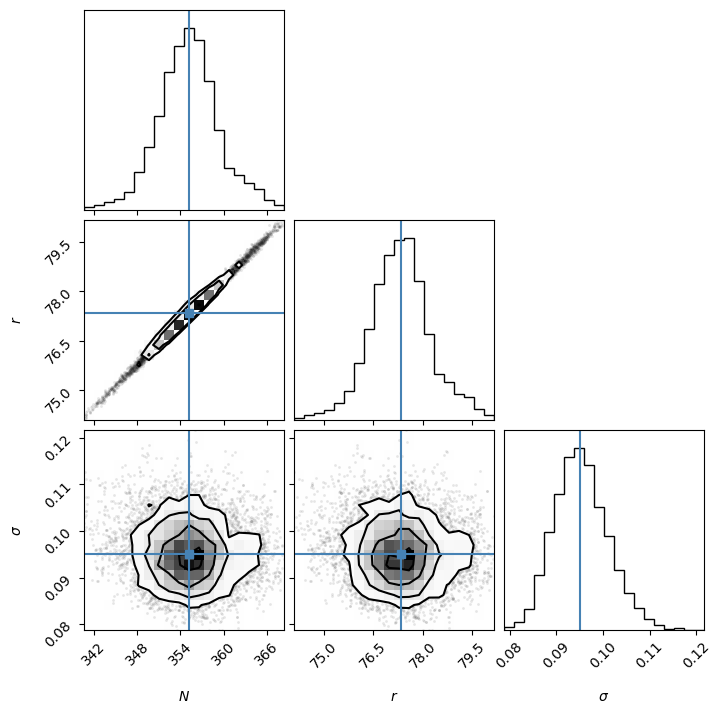

In [18]:
# Corner plot for the parameters
samples = mcmc.get_samples()

# Format data for arviz
samples_arviz = {'N': np.array(samples['N']),
    'r': np.array(samples['r']),
    'sigma': np.array(samples['sigma'])}

data = az.from_dict(posterior=samples_arviz)

labels = [r'$N$', r'$r$', r'$\sigma$']

figure = corner.corner(data,labels=labels, truths={"N": 355.24, "r": 77.34, "sigma": 0.095})


array([[<Axes: title={'center': 'N'}>, <Axes: title={'center': 'N'}>],
       [<Axes: title={'center': 'alpha_j'}>,
        <Axes: title={'center': 'alpha_j'}>],
       [<Axes: title={'center': 'model'}>,
        <Axes: title={'center': 'model'}>],
       [<Axes: title={'center': 'r'}>, <Axes: title={'center': 'r'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'x_0j'}>,
        <Axes: title={'center': 'x_0j'}>],
       [<Axes: title={'center': 'y_0j'}>,
        <Axes: title={'center': 'y_0j'}>]], dtype=object)

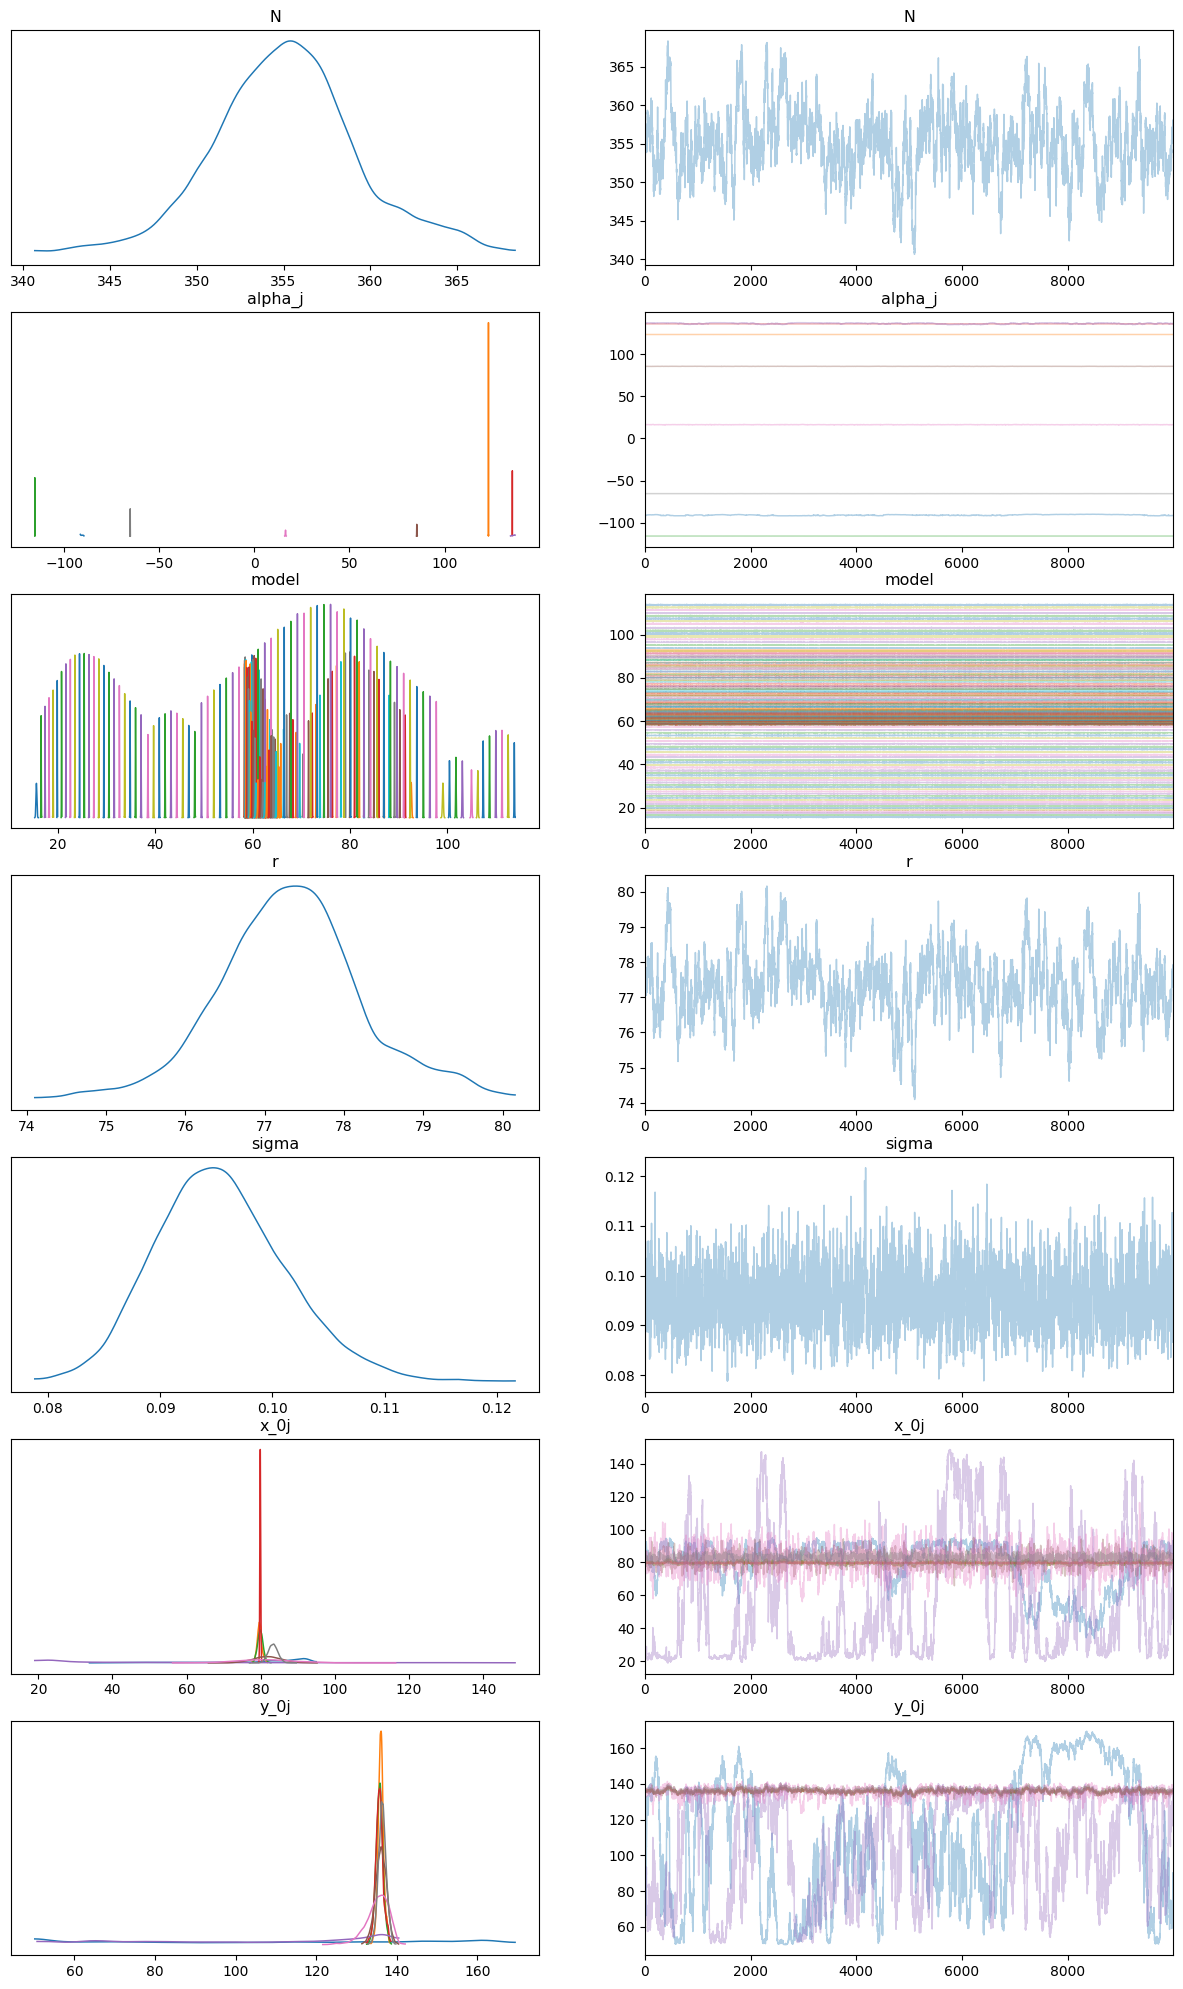

In [19]:
# Inspecting the learned parameters
data = az.from_numpyro(mcmc)
az.plot_trace(data, compact=True, figsize=(15, 25))

### Posterior Predictive Distribution

[[[ 15.374276  92.64843 ]
  [ 16.560192  91.292274]
  [ 17.362047  90.18556 ]
  ...
  [111.21063   64.28525 ]
  [112.48815   64.77076 ]
  [113.7563    65.27868 ]]

 [[ 15.434724  92.63554 ]
  [ 16.654903  91.4034  ]
  [ 17.451149  90.29069 ]
  ...
  [111.2488    64.32638 ]
  [112.53155   64.80249 ]
  [113.805084  65.30112 ]]

 [[ 15.605172  92.629   ]
  [ 16.547583  91.332504]
  [ 17.348743  90.22586 ]
  ...
  [111.27638   64.35342 ]
  [112.55733   64.82849 ]
  [113.829636  65.326256]]

 ...

 [[ 15.616279  92.61119 ]
  [ 16.579449  91.38003 ]
  [ 17.379097  90.26947 ]
  ...
  [111.229355  64.2608  ]
  [112.502335  64.76311 ]
  [113.766304  65.28769 ]]

 [[ 15.63073   92.601135]
  [ 16.51711   91.30546 ]
  [ 17.323587  90.20111 ]
  ...
  [111.269684  64.29009 ]
  [112.538216  64.80079 ]
  [113.79704   65.333435]]

 [[ 15.696999  92.626755]
  [ 16.631735  91.41073 ]
  [ 17.427841  90.29845 ]
  ...
  [111.25772   64.34493 ]
  [112.52635   64.85632 ]
  [113.785515  65.389854]]]


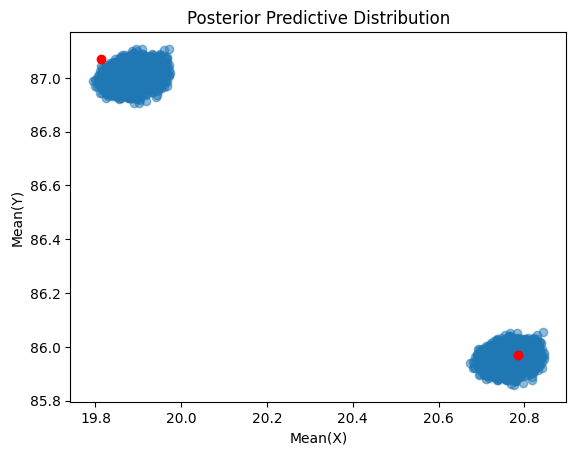

In [20]:
# Creating a posterior predictive distribution
predictive = numpyro.infer.Predictive(model, samples)

# Generate random samples from the prior
data_points = jnp.array(df[["Mean(X)", "Mean(Y)"]].to_numpy())
predictions = predictive(rng_key=jax.random.PRNGKey(0), data=data_points)['model']
print(predictions)

# Visualizing posterior predictions
plt.scatter(predictions[:,5:7,0], predictions[:,5:7,1], alpha=0.5)
plt.scatter(df["Mean(X)"][5:7], df["Mean(Y)"][5:7], c='r')
plt.title("Posterior Predictive Distribution")
plt.xlabel("Mean(X)")
plt.ylabel("Mean(Y)")
plt.show()

### Log Likelihood

In [21]:
# defining the log likelihood function
def log_likelihood(intended_positions, sigma, data_points):
    """
    Calculate the log likelihood of observed data given intended positions and standard deviation.

    Parameters:
    - intended_positions (jax.numpy.ndarray): An array of shape (n, 2) representing the intended x and y coordinates for 
        each of n data points.
    - sigma (float): Standard deviation of the normal distribution, used to construct the covariance matrix.
    - data_points (jax.numpy.ndarray): An array of shape (n, 2) containing the observed x and y coordinates to be evaluated.

    Returns:
    jax.numpy.DeviceArray: The log likelihood of the data points given the intended positions and specified sigma.
    """
    cov = jnp.array([[sigma**2, 0], [0, sigma**2]])
    return numpyro.distributions.MultivariateNormal(loc=intended_positions, covariance_matrix=cov).log_prob(data_points)

In [22]:
# defining negative log likelihood function
def neg_log_likelihood_function(params, data_points):
    """
    Calculate the negative log likelihood for a set of parameters and observed data.

    This function computes the negative log likelihood of observed data points, given a specified set of parameters.

    Parameters:
    params (list or array-like): A list or array containing the parameters:
        - N (int): Number of divisions used for angle calculations.
        - r (float): Radius affecting the distance of calculated positions from their arc-center.
        - sigma (float): Standard deviation for the normal distribution of data points.
        - x_0j (list): X-coordinates of centers for each segment, provided as a slice from indices 3 to 10.
        - y_0j (list): Y-coordinates of centers for each segment, provided as a slice from indices 11 to 18.
        - alpha_j (list): Angular offsets for each segment, provided as a slice from indices 19 to 26.
        data_points (jax.numpy.ndarray): An array of shape (n, 2) containing the observed x and y coordinates.

    Returns:
        float: The negative log likelihood of the data points given the model parameters.
    """
    N = params[0]
    r = params[1]
    sigma = params[2]
    x_0j = params[3:11]
    y_0j = params[11:19]
    alpha_j = params[19:27]
    intended_positions = holes_locations(N, r, 
                            x_0j[0], x_0j[1], x_0j[2], x_0j[3], x_0j[4], x_0j[5], x_0j[6], x_0j[7],
                            y_0j[0], y_0j[1], y_0j[2], y_0j[3], y_0j[4], y_0j[5], y_0j[6], y_0j[7], 
                            alpha_j[0], alpha_j[1], alpha_j[2], alpha_j[3], alpha_j[4], alpha_j[5], alpha_j[6], alpha_j[7])
    return -jnp.sum(log_likelihood(intended_positions, sigma, data_points))

data_points = jnp.array(df[["Mean(X)", "Mean(Y)"]].to_numpy())

#gradient calculation function
grad_neg_log_likelihood = jax.grad(neg_log_likelihood_function)


In [23]:
# example of gradient calculation
grad_neg_log_likelihood(jnp.array([350, 70, 0.1, 75,75,75,75,75,75,75,75,
                125,125,125,125,125,125,125,125, 0,0,0,0,0,0,0,0]), data_points)

Array([-4.7608441e+04,  1.0031101e+06, -1.3703476e+09,  1.2938941e+04,
        2.5754538e+05,  8.4759820e+04,  1.6795377e+05, -9.6466064e+00,
       -1.5430793e+03, -2.3995933e+03, -1.3117025e+04,  3.1146904e+03,
        1.2586090e+05,  7.9889789e+04,  4.3638603e+05,  1.3004486e+04,
        3.9021641e+04,  2.6022922e+04,  7.7690703e+04,  2.3425188e+05,
        5.3304135e+06,  2.3276125e+06,  1.0628355e+07,  3.1283303e+05,
        9.4689825e+05,  6.4654825e+05,  1.9679116e+06], dtype=float32)

In [24]:
# example of gradient calculation
grad_neg_log_likelihood(jnp.array([355.24, 77.34, 0.1, 79,79,79,79,79,79,79,79,
                135,135,135,135,135,135,135,135, -145,-145,-145,-145,-145,-145,-145,-145]), data_points)

Array([-8.3912008e+04,  9.0115175e+05, -1.3838694e+09,  1.3110828e+04,
        2.7752822e+05,  1.0166734e+05,  2.8171538e+05,  3.8245193e+03,
        1.0121609e+04,  5.5012134e+03,  1.1085717e+04,  5.0248718e+02,
        6.9059523e+04,  5.8702652e+04,  3.8171078e+05,  1.2505354e+04,
        3.7888402e+04,  2.5575879e+04,  7.7867953e+04,  5.2408653e+05,
        1.1542253e+07,  4.7546950e+06,  1.9686612e+07,  5.3552562e+05,
        1.6071324e+06,  1.0805059e+06,  3.2482208e+06], dtype=float32)

In [25]:
# define initial parameters
initial_params = jnp.array([350, 70, 0.1, 75,75,75,75,75,75,75,75,
                125,125,125,125,125,125,125,125, 0,0,0,0,0,0,0,0])

# Optimization
min = opt.minimize(neg_log_likelihood_function, initial_params, args=(data_points), method='L-BFGS-B',
                    jac=jax.jit(jax.grad(neg_log_likelihood_function)))

In [26]:
min

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -115.30780029296875
        x: [ 3.398e+02  7.399e+01 ... -2.456e+00 -2.464e+00]
      nit: 1026
      jac: [ 2.515e-01 -3.874e+00 ... -3.643e+00 -1.048e+01]
     nfev: 1136
     njev: 1136
 hess_inv: <27x27 LbfgsInvHessProduct with dtype=float64>

In [27]:
# Extracting and printing MLE parameters
mle_N = min.x[0]
mle_r = min.x[1]
mle_sigma = min.x[2]
mle_x_0j = min.x[3:11]
mle_y_0j = min.x[11:19]
mle_alpha_j = min.x[19:27]

print("MLE N:", mle_N)
print("MLE r:", mle_r)
print("MLE Sigma:", mle_sigma)
print("MLE x_0j:", mle_x_0j)
print("MLE y_0j:", mle_y_0j)
print("MLE alpha_j:", mle_alpha_j)

MLE N: 339.786562497069
MLE r: 73.99015279444298
MLE Sigma: 0.11889756540217064
MLE x_0j: [80.52647966 77.1581037  78.92004379 79.61975858 73.08121885 73.03149346
 73.12616616 73.73426039]
MLE y_0j: [128.06321694 133.80891097 132.43875048 132.29850848 130.00731273
 129.7133046  128.7775883  128.2356839 ]
MLE alpha_j: [-2.62317127 -2.530411   -2.55493885 -2.56253081 -2.46901134 -2.46649847
 -2.45645306 -2.4638475 ]


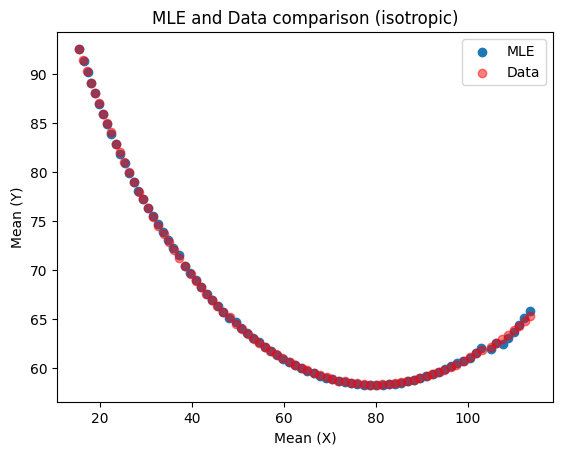

In [28]:
MLE_test = holes_locations(N=mle_N, r=mle_r, 
                            x_00=mle_x_0j[0], x_01=mle_x_0j[1], x_02=mle_x_0j[2], x_03=mle_x_0j[3], x_04=mle_x_0j[4], x_05=mle_x_0j[5], x_06=mle_x_0j[6], x_07=mle_x_0j[7],
                            y_00=mle_y_0j[0], y_01=mle_y_0j[1], y_02=mle_y_0j[2], y_03=mle_y_0j[3], y_04=mle_y_0j[4], y_05=mle_y_0j[5], y_06=mle_y_0j[6], y_07=mle_y_0j[7], 
                            alpha_0=mle_alpha_j[0], alpha_1=mle_alpha_j[1], alpha_2=mle_alpha_j[2], alpha_3=mle_alpha_j[3], alpha_4=mle_alpha_j[4], alpha_5=mle_alpha_j[5], alpha_6=mle_alpha_j[6], alpha_7=mle_alpha_j[7])

# max likelihood parameters plot
plt.scatter(MLE_test[:,0], MLE_test[:,1], label = 'MLE')
plt.scatter(df["Mean(X)"], df["Mean(Y)"], c='r', alpha=0.5, label = "Data")
plt.title("MLE and Data comparison (isotropic)")
plt.xlabel("Mean (X)")
plt.ylabel("Mean (Y)")
plt.legend()
plt.show()

### Log likelihood (from samples)

In [29]:
# obtaining log likelihood
log_L = numpyro.infer.log_likelihood(model, samples, data=data_points)

# calculating the log likelihood of all 81pts with given set of params
list_likelihoods = np.zeros(len(log_L['obs']))
for i in range (len(log_L['obs'])):
    list_likelihoods[i] = log_L['obs'][i].sum()

#plt.hist(list_likelihoods)

In [30]:
# obtaining max_likelihood index and then parameters at that index
max_log_l_index = np.argmax(list_likelihoods)
max_logL_N = samples['N'][max_log_l_index]
max_logL_r = samples['r'][max_log_l_index]
max_logL_sigma = samples['sigma'][max_log_l_index]

max_logL_N

Array(358.27863, dtype=float32)

Text(0.5, 0.98, 'Maximum Log Likelihood Parameters (estimated from samples)')

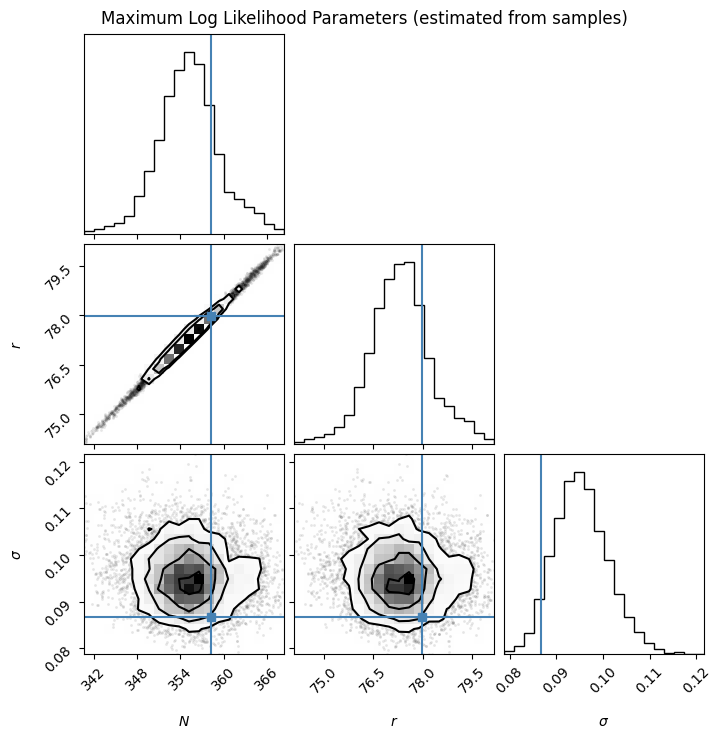

In [31]:
# Corner plot for the parameters
samples = mcmc.get_samples()

# Format data for arviz
samples_arviz = {'N': np.array(samples['N']),
    'r': np.array(samples['r']),
    'sigma': np.array(samples['sigma'])}

data = az.from_dict(posterior=samples_arviz)

labels = [r'$N$', r'$r$', r'$\sigma$']

figure = corner.corner(data,labels=labels, truths={"N": max_logL_N, "r": max_logL_r, "sigma": max_logL_sigma})
figure.suptitle("Maximum Log Likelihood Parameters (estimated from samples)")

In [32]:
ML_data_test = holes_locations(N=samples['N'][max_log_l_index], r=samples['r'][max_log_l_index], 
                            x_00=samples['x_0j'][max_log_l_index][0], x_01=samples['x_0j'][max_log_l_index][1], x_02=samples['x_0j'][max_log_l_index][2], x_03=samples['x_0j'][max_log_l_index][3], x_04=samples['x_0j'][max_log_l_index][4], x_05=samples['x_0j'][max_log_l_index][5], x_06=samples['x_0j'][max_log_l_index][6], x_07=samples['x_0j'][max_log_l_index][7],
                            y_00=samples['y_0j'][max_log_l_index][0], y_01=samples['y_0j'][max_log_l_index][1], y_02=samples['y_0j'][max_log_l_index][2], y_03=samples['y_0j'][max_log_l_index][3], y_04=samples['y_0j'][max_log_l_index][4], y_05=samples['y_0j'][max_log_l_index][5], y_06=samples['y_0j'][max_log_l_index][6], y_07=samples['y_0j'][max_log_l_index][7], 
                            alpha_0=samples['alpha_j'][max_log_l_index][0], alpha_1=samples['alpha_j'][max_log_l_index][1], alpha_2=samples['alpha_j'][max_log_l_index][2], alpha_3=samples['alpha_j'][max_log_l_index][3], alpha_4=samples['alpha_j'][max_log_l_index][4], alpha_5=samples['alpha_j'][max_log_l_index][5], alpha_6=samples['alpha_j'][max_log_l_index][6], alpha_7=samples['alpha_j'][max_log_l_index][7])

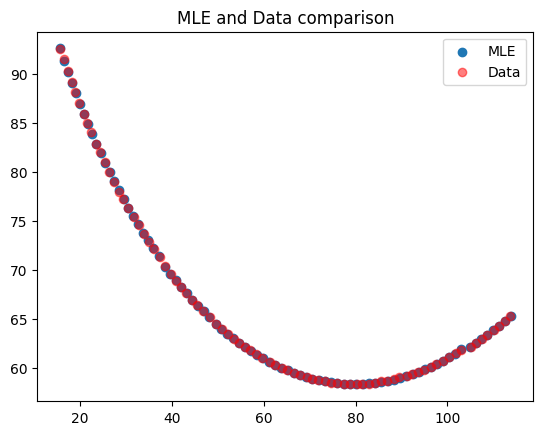

In [33]:
# max likelihood parameters plot
plt.scatter(ML_data_test[:,0], ML_data_test[:,1], label = 'MLE')
plt.scatter(df["Mean(X)"], df["Mean(Y)"], c='r', alpha=0.5, label = "Data")
plt.title("MLE and Data comparison")
plt.legend()
plt.show()

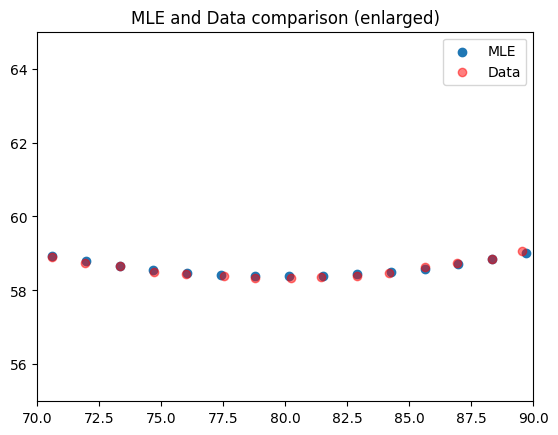

In [34]:
# max likelihood parameters plot
plt.scatter(ML_data_test[:,0], ML_data_test[:,1], label = 'MLE')
plt.scatter(df["Mean(X)"], df["Mean(Y)"], c='r', alpha=0.5, label = "Data")
plt.title("MLE and Data comparison (enlarged)")
plt.xlim(70,90)
plt.ylim(55,65)
plt.legend()
plt.show()

#### LogL Derivative Calculation

In [35]:
# Function to compute log-likelihood
def log_likelihood_fn(N, r, sigma, alpha_j, x_0j, y_0j, data):
    s = 8  # Number of sections
    num_points = 81
    cov = jnp.array([[sigma**2, 0], [0, sigma**2]])

    model_ll = numpyro.deterministic("model_ll", holes_locations(N, r, 
                            x_0j[0], x_0j[1], x_0j[2], x_0j[3], x_0j[4], x_0j[5], x_0j[6], x_0j[7],
                            y_0j[0], y_0j[1], y_0j[2], y_0j[3], y_0j[4], y_0j[5], y_0j[6], y_0j[7], 
                            alpha_j[0], alpha_j[1], alpha_j[2], alpha_j[3], alpha_j[4], alpha_j[5], alpha_j[6], alpha_j[7]))
        
    with numpyro.plate("data", num_points):
        distr =  numpyro.distributions.MultivariateNormal(model_ll, covariance_matrix=cov)
    
    log_prob = distr.log_prob(data) 
    return jnp.sum(log_prob)

N_maxL = samples['N'][max_log_l_index]
r_maxL = samples['r'][max_log_l_index]
sigma_maxL = samples['sigma'][max_log_l_index]
alpha_j_maxL = samples['alpha_j'][max_log_l_index]
x_0j_maxL = samples['x_0j'][max_log_l_index]
y_0j_maxL = samples['y_0j'][max_log_l_index]

# Calculate log-likelihood using the parameter samples
log_L = log_likelihood_fn(N_maxL, r_maxL, sigma_maxL, 
                            alpha_j_maxL, x_0j_maxL, y_0j_maxL, data_points)

# Calculate gradients if necessary
grad_log_L = jax.grad(log_likelihood_fn)(N_maxL, r_maxL, sigma_maxL, 
                                        alpha_j_maxL, x_0j_maxL, y_0j_maxL, data_points)

# Output results
print("Log-Likelihood:", log_L)
print("Gradient of Log-Likelihood:", grad_log_L)

Log-Likelihood: 161.20421
Gradient of Log-Likelihood: 21.150816


In [36]:
for i in range(0, 100): #1000 used before here
    N_sample = samples['N'][i]
    r_sample = samples['r'][i]
    sigma_sample = samples['sigma'][i]
    alpha_j_sample = samples['alpha_j'][i]
    x_0j_sample = samples['x_0j'][i]
    y_0j_sample = samples['y_0j'][i]

    # Calculate log-likelihood using the parameter samples
    log_L = log_likelihood_fn(N_sample, r_sample, sigma_sample, 
                            alpha_j_sample, x_0j_sample, y_0j_sample, data_points)

    # Calculate gradients if necessary
    grad_log_L = jax.grad(log_likelihood_fn)(N_sample, r_sample, sigma_sample, 
                                        alpha_j_sample, x_0j_sample, y_0j_sample, data_points)

    if (np.isclose(grad_log_L, 0, rtol = 1e-2, atol = 1e-2)):
        print("Index:", i)
    # Output results
    #print("Log-Likelihood:", log_L)
    #print("Gradient of Log-Likelihood:", grad_log_L)

Index: 17


In [37]:
print("N from grad:", N_sample, ", from max(log_likelihood):", N_maxL)
print("r from grad:", r_sample, ", from max(log_likelihood):", r_maxL)
print("sigma from grad:", sigma_sample, ", from max(log_likelihood):", sigma_maxL)

N from grad: 355.49136 , from max(log_likelihood): 358.27863
r from grad: 77.290825 , from max(log_likelihood): 77.97768
sigma from grad: 0.09701514 , from max(log_likelihood): 0.08680683


For the first 1000 samples, it is 17th that is the closest to 0. The code with first 100 samples is left for the sake of eliminating "unnecessary" evaluations.

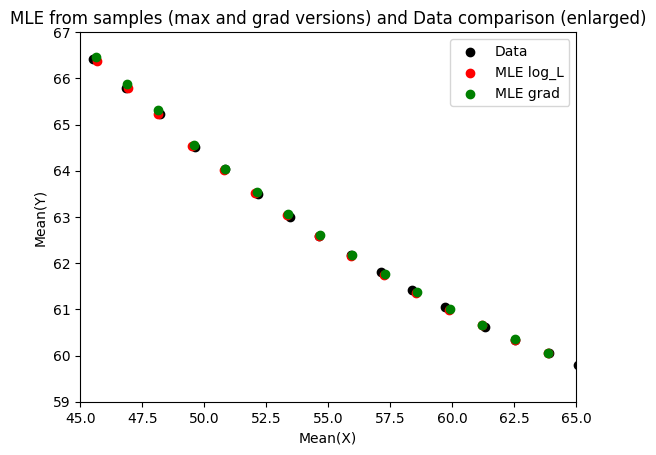

In [38]:
ML_data_test1 = holes_locations(N=samples['N'][17], r=samples['r'][17], 
                            x_00=samples['x_0j'][17][0], x_01=samples['x_0j'][17][1], x_02=samples['x_0j'][17][2], x_03=samples['x_0j'][17][3], x_04=samples['x_0j'][17][4], x_05=samples['x_0j'][17][5], x_06=samples['x_0j'][17][6], x_07=samples['x_0j'][17][7],
                            y_00=samples['y_0j'][17][0], y_01=samples['y_0j'][17][1], y_02=samples['y_0j'][17][2], y_03=samples['y_0j'][17][3], y_04=samples['y_0j'][17][4], y_05=samples['y_0j'][17][5], y_06=samples['y_0j'][17][6], y_07=samples['y_0j'][17][7], 
                            alpha_0=samples['alpha_j'][17][0], alpha_1=samples['alpha_j'][17][1], alpha_2=samples['alpha_j'][17][2], alpha_3=samples['alpha_j'][17][3], alpha_4=samples['alpha_j'][17][4], alpha_5=samples['alpha_j'][17][5], alpha_6=samples['alpha_j'][17][6], alpha_7=samples['alpha_j'][17][7])

# parameters plot
plt.scatter(df["Mean(X)"], df["Mean(Y)"], c='black', label = "Data")
plt.scatter(ML_data_test[:,0], ML_data_test[:,1], c='red', label = 'MLE log_L')
plt.scatter(ML_data_test1[:,0], ML_data_test1[:,1], c='green', label = 'MLE grad')
plt.title("MLE from samples (max and grad versions) and Data comparison (enlarged)")
plt.xlim(45,65)
plt.ylim(59,67)
plt.xlabel("Mean(X)")
plt.ylabel("Mean(Y)")
plt.legend()
plt.show()

## Model with radial and tangential errors

In [39]:
# defining the model which outputs 81 holes locations based on segments' inputs
def holes_locations_rt(N, r, sigma_r, sigma_t,
                        x_00, x_01, x_02, x_03, x_04, x_05, x_06, x_07,
                        y_00, y_01, y_02, y_03, y_04, y_05, y_06, y_07, 
                        alpha_0, alpha_1, alpha_2, alpha_3, alpha_4, alpha_5, alpha_6, alpha_7, 
                        s=8, num_holes=81):
    """
    Calculate intended hole positions and their associated covariance matrices based 
    on parameters.

    This function computes the intended positions for 81 holes distributed across 
    multiple segments, taking into account the radial and tangential uncertainties. 
    The covariance matrices for each hole are aligned with the radial and tangential 
    directions at each position.

    Parameters:
    - N (int): Total number of divisions used for angle calculations.
    - r (float): Radius that influences the distance of the holes from their arc-center.
    - sigma_r (float): Standard deviation for radial uncertainty.
    - sigma_t (float): Standard deviation for tangential uncertainty.
    - x_00 to x_07 (float): X-coordinates of the center for each corresponding segment.
    - y_00 to y_07 (float): Y-coordinates of the center for each corresponding segment.
    - alpha_0 to alpha_7 (float): Angular offsets for each segment, influencing hole spacing in radians.
    - s (int, optional): Number of segments to consider. Default is 8.
    - num_holes (int, optional): Total number of holes to place, default is 81.

    Returns:
        A tuple containing:
            - jax.numpy.ndarray: An array of shape (81, 2) with the x and y coordinates of the hole positions.
            - jax.numpy.ndarray: An array of shape (81, 2, 2) containing the covariance matrices for each hole position, 
            aligned with radial and tangential directions.
    """

    intended_positions = jnp.zeros((num_holes, 2))
    covariances = jnp.zeros((num_holes, 2, 2))

    for i in range(num_holes):
        if i in seg_cords_0:   
            phi_ij = 2 * jnp.pi * (i - 1) / N + alpha_0 # angular position of the ith hole in the jth section with respect to its arc-centre
            r_ij = jnp.array([jnp.cos(phi_ij), jnp.sin(phi_ij)])*r  #distance from jth centre 
            intended_pos_ij = r_ij + jnp.array([x_00, y_00]) # Intended hole position
            intended_positions = intended_positions.at[i].set(intended_pos_ij)

            # aligning covariance matrix with tangential and radial directions
            rotation_matrix = jnp.array([[jnp.cos(phi_ij), jnp.sin(phi_ij)], [jnp.sin(phi_ij), -jnp.cos(phi_ij)]]).T
            cov_rt = jnp.diag(jnp.array([sigma_r**2, sigma_t**2]))
            cov_xy = rotation_matrix @ cov_rt @ rotation_matrix.T # transform cov matrix to (x,y) coords
            covariances = covariances.at[i].set(cov_xy)
        
        elif i in seg_cords_1:   
            phi_ij = 2 * jnp.pi * (i - 1) / N + alpha_1 # angular position of the ith hole in the jth section with respect to its arc-centre
            r_ij = jnp.array([jnp.cos(phi_ij), jnp.sin(phi_ij)])*r  #distance from jth centre 
            intended_pos_ij = r_ij + jnp.array([x_01, y_01]) # Intended hole position
            intended_positions = intended_positions.at[i].set(intended_pos_ij)

            # aligning covariance matrix with tangential and radial directions
            rotation_matrix = jnp.array([[jnp.cos(phi_ij), jnp.sin(phi_ij)], [jnp.sin(phi_ij), -jnp.cos(phi_ij)]]).T
            cov_rt = jnp.diag(jnp.array([sigma_r**2, sigma_t**2]))
            cov_xy = rotation_matrix @ cov_rt @ rotation_matrix.T # transform cov matrix to (x,y) coords
            covariances = covariances.at[i].set(cov_xy)

        elif i in seg_cords_2:   
            phi_ij = 2 * jnp.pi * (i - 1) / N + alpha_2 # angular position of the ith hole in the jth section with respect to its arc-centre
            r_ij = jnp.array([jnp.cos(phi_ij), jnp.sin(phi_ij)])*r  #distance from jth centre 
            intended_pos_ij = r_ij + jnp.array([x_02, y_02]) # Intended hole position
            intended_positions = intended_positions.at[i].set(intended_pos_ij)

            # aligning covariance matrix with tangential and radial directions
            rotation_matrix = jnp.array([[jnp.cos(phi_ij), jnp.sin(phi_ij)], [jnp.sin(phi_ij), -jnp.cos(phi_ij)]]).T
            cov_rt = jnp.diag(jnp.array([sigma_r**2, sigma_t**2]))
            cov_xy = rotation_matrix @ cov_rt @ rotation_matrix.T # transform cov matrix to (x,y) coords
            covariances = covariances.at[i].set(cov_xy)

        elif i in seg_cords_3:   
            phi_ij = 2 * jnp.pi * (i - 1) / N + alpha_3 # angular position of the ith hole in the jth section with respect to its arc-centre
            r_ij = jnp.array([jnp.cos(phi_ij), jnp.sin(phi_ij)])*r  #distance from jth centre 
            intended_pos_ij = r_ij + jnp.array([x_03, y_03]) # Intended hole position
            intended_positions = intended_positions.at[i].set(intended_pos_ij)

            # aligning covariance matrix with tangential and radial directions
            rotation_matrix = jnp.array([[jnp.cos(phi_ij), jnp.sin(phi_ij)], [jnp.sin(phi_ij), -jnp.cos(phi_ij)]]).T
            cov_rt = jnp.diag(jnp.array([sigma_r**2, sigma_t**2]))
            cov_xy = rotation_matrix @ cov_rt @ rotation_matrix.T # transform cov matrix to (x,y) coords
            covariances = covariances.at[i].set(cov_xy)

        elif i in seg_cords_4:   
            phi_ij = 2 * jnp.pi * (i - 1) / N + alpha_4 # angular position of the ith hole in the jth section with respect to its arc-centre
            r_ij = jnp.array([jnp.cos(phi_ij), jnp.sin(phi_ij)])*r  #distance from jth centre 
            intended_pos_ij = r_ij + jnp.array([x_04, y_04]) # Intended hole position
            intended_positions = intended_positions.at[i].set(intended_pos_ij)

            # aligning covariance matrix with tangential and radial directions
            rotation_matrix = jnp.array([[jnp.cos(phi_ij), jnp.sin(phi_ij)], [jnp.sin(phi_ij), -jnp.cos(phi_ij)]]).T
            cov_rt = jnp.diag(jnp.array([sigma_r**2, sigma_t**2]))
            cov_xy = rotation_matrix @ cov_rt @ rotation_matrix.T # transform cov matrix to (x,y) coords
            covariances = covariances.at[i].set(cov_xy)

        elif i in seg_cords_5:   
            phi_ij = 2 * jnp.pi * (i - 1) / N + alpha_5 # angular position of the ith hole in the jth section with respect to its arc-centre
            r_ij = jnp.array([jnp.cos(phi_ij), jnp.sin(phi_ij)])*r  #distance from jth centre 
            intended_pos_ij = r_ij + jnp.array([x_05, y_05]) # Intended hole position
            intended_positions = intended_positions.at[i].set(intended_pos_ij)

            # aligning covariance matrix with tangential and radial directions
            rotation_matrix = jnp.array([[jnp.cos(phi_ij), jnp.sin(phi_ij)], [jnp.sin(phi_ij), -jnp.cos(phi_ij)]]).T
            cov_rt = jnp.diag(jnp.array([sigma_r**2, sigma_t**2]))
            cov_xy = rotation_matrix @ cov_rt @ rotation_matrix.T # transform cov matrix to (x,y) coords
            covariances = covariances.at[i].set(cov_xy)

        elif i in seg_cords_6:   
            phi_ij = 2 * jnp.pi * (i - 1) / N + alpha_6 # angular position of the ith hole in the jth section with respect to its arc-centre
            r_ij = jnp.array([jnp.cos(phi_ij), jnp.sin(phi_ij)])*r  #distance from jth centre 
            intended_pos_ij = r_ij + jnp.array([x_06, y_06]) # Intended hole position
            intended_positions = intended_positions.at[i].set(intended_pos_ij)

            # aligning covariance matrix with tangential and radial directions
            rotation_matrix = jnp.array([[jnp.cos(phi_ij), jnp.sin(phi_ij)], [jnp.sin(phi_ij), -jnp.cos(phi_ij)]]).T
            cov_rt = jnp.diag(jnp.array([sigma_r**2, sigma_t**2]))
            cov_xy = rotation_matrix @ cov_rt @ rotation_matrix.T # transform cov matrix to (x,y) coords
            covariances = covariances.at[i].set(cov_xy)

        elif i in seg_cords_7:   
            phi_ij = 2 * jnp.pi * (i - 1) / N + alpha_7 # angular position of the ith hole in the jth section with respect to its arc-centre
            r_ij = jnp.array([jnp.cos(phi_ij), jnp.sin(phi_ij)])*r  #distance from jth centre 
            intended_pos_ij = r_ij + jnp.array([x_07, y_07]) # Intended hole position
            intended_positions = intended_positions.at[i].set(intended_pos_ij)

            # aligning covariance matrix with tangential and radial directions
            rotation_matrix = jnp.array([[jnp.cos(phi_ij), jnp.sin(phi_ij)], [jnp.sin(phi_ij), -jnp.cos(phi_ij)]]).T
            cov_rt = jnp.diag(jnp.array([sigma_r**2, sigma_t**2]))
            cov_xy = rotation_matrix @ cov_rt @ rotation_matrix.T # transform cov matrix to (x,y) coords
            covariances = covariances.at[i].set(cov_xy)

    return intended_positions, covariances

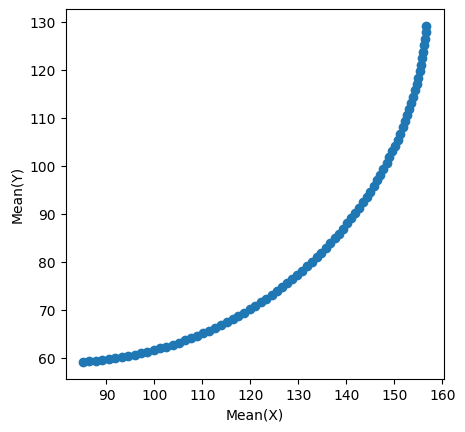

In [40]:
# mock data production
mock_data_rt, covs = holes_locations_rt(N=355, r=77, sigma_r=0.2, sigma_t=0.09, 
                            x_00=80, x_01=80, x_02=80, x_03=80, x_04=80, x_05=80, x_06=80, x_07=80,
                            y_00=136, y_01=136, y_02=136, y_03=136, y_04=136, y_05=136, y_06=136, y_07=136, 
                            alpha_0=-146, alpha_1=-146, alpha_2=-146, alpha_3=-146, alpha_4=-146, alpha_5=-146, alpha_6=-146, alpha_7=-146)
plt.scatter(mock_data_rt[:,0], mock_data_rt[:,1])
plt.xlabel("Mean(X)")
plt.ylabel("Mean(Y)")
# Set equal scaling for the x and y axes
plt.gca().set_aspect('equal')

In [41]:
# model with a 2-dimensional isotropic Gaussian distribution with standard deviation sigma
def model_rt(data):
    s = 8 # Number of sections
    num_points = 81

    # Defining priors
    N = numpyro.sample("N", numpyro.distributions.Uniform(340., 370.)) 
    r = numpyro.sample("r", numpyro.distributions.Uniform(50., 100.))
    sigma_r = numpyro.sample("sigma_r", numpyro.distributions.Uniform(0., 1))
    sigma_t = numpyro.sample("sigma_t", numpyro.distributions.Uniform(0., 1))

    alpha_j = numpyro.sample("alpha_j", numpyro.distributions.Uniform(-180., 180.).expand([s])) # angular position of the first hole
    x_0j = numpyro.sample("x_0j", numpyro.distributions.Uniform(0., 150.).expand([s]))
    y_0j = numpyro.sample("y_0j", numpyro.distributions.Uniform(50., 200.).expand([s]))

    model_rt, covariances =  holes_locations_rt(N, r, sigma_r, sigma_t,
                            x_0j[0], x_0j[1], x_0j[2], x_0j[3], x_0j[4], x_0j[5], x_0j[6], x_0j[7],
                            y_0j[0], y_0j[1], y_0j[2], y_0j[3], y_0j[4], y_0j[5], y_0j[6], y_0j[7], 
                            alpha_j[0], alpha_j[1], alpha_j[2], alpha_j[3], alpha_j[4], alpha_j[5], alpha_j[6], alpha_j[7])
        
    with numpyro.plate("data", num_points):
        numpyro.sample("obs", numpyro.distributions.MultivariateNormal(loc = model_rt, covariance_matrix = covariances), obs=data)

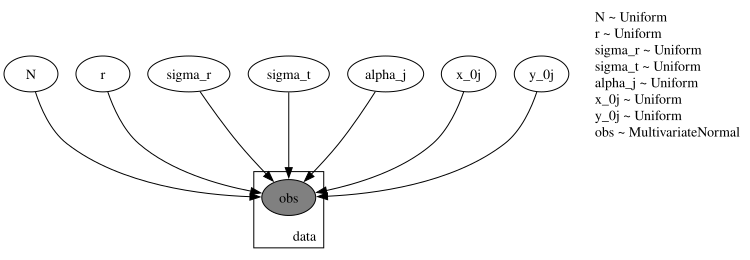

In [42]:
data_points = jnp.array(df[["Mean(X)", "Mean(Y)"]].to_numpy())

numpyro.render_model(
    model=model_rt,
    model_kwargs={"data": data_points},
    render_distributions=True,
    render_params=True,
)

### Prior Predictive Distribution (Complex Model)

dict_keys(['N', 'alpha_j', 'obs', 'r', 'sigma_r', 'sigma_t', 'x_0j', 'y_0j'])
[[[  3.0674107  85.43589  ]
  [-30.710043  196.48558  ]
  [-31.107557  195.50688  ]
  ...
  [ 75.86865   188.58916  ]
  [ 76.011086  189.57838  ]
  [ 76.10616   190.5403   ]]

 [[162.21996    57.84866  ]
  [ 81.79809    19.169678 ]
  [ 82.638405   18.205194 ]
  ...
  [ 62.122208   67.023544 ]
  [ 64.05219    68.29278  ]
  [ 65.449394   68.77583  ]]

 [[-62.075436  161.06255  ]
  [ 88.37559   248.87679  ]
  [ 86.03169   249.99069  ]
  ...
  [ 18.689568  237.57751  ]
  [ 18.05454   236.77486  ]
  [ 16.018822  235.62923  ]]

 ...

 [[167.05246   185.5316   ]
  [-45.988323  111.2493   ]
  [-46.62932   110.41229  ]
  ...
  [215.4658    177.30083  ]
  [215.7382    178.48772  ]
  [215.07326   179.60583  ]]

 [[ 50.390446  145.06714  ]
  [151.89572   133.55574  ]
  [149.76636   133.27803  ]
  ...
  [157.52979   103.80383  ]
  [157.66498   105.180725 ]
  [157.32642   106.69104  ]]

 [[-66.61231   130.61673  ]
  [-13.6

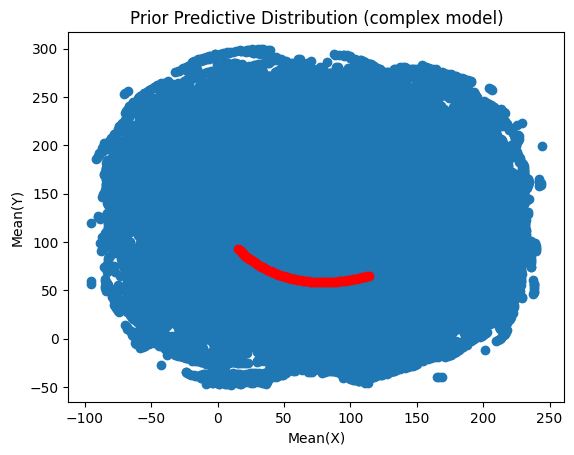

In [43]:
# Create a predictive object
predictive_rt = numpyro.infer.Predictive(model_rt, num_samples=1000)

# Generate random samples from the prior
prior_samples_rt = predictive_rt(rng_key=jax.random.PRNGKey(0), data=None)
print(prior_samples_rt.keys())

# Visualize prior predictions
observations_rt = prior_samples_rt['obs']
print(observations_rt)

# Visualizing prior predictions
plt.scatter(observations_rt[:,:,0],observations_rt[:,:,1])
plt.scatter(df["Mean(X)"], df["Mean(Y)"], c='r')
plt.xlabel("Mean(X)")
plt.ylabel("Mean(Y)")
plt.title("Prior Predictive Distribution (complex model)")
plt.show()

/Users/ilyakogan/Desktop/venvs/s2coursework/lib/python3.13/site-packages/arviz/data/base.py:272: UserWarning: More chains (1000) than draws (8). Passed array should have shape (chains, draws, *shape)
  warnings.warn(
/Users/ilyakogan/Desktop/venvs/s2coursework/lib/python3.13/site-packages/arviz/data/base.py:272: UserWarning: More chains (1000) than draws (81). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


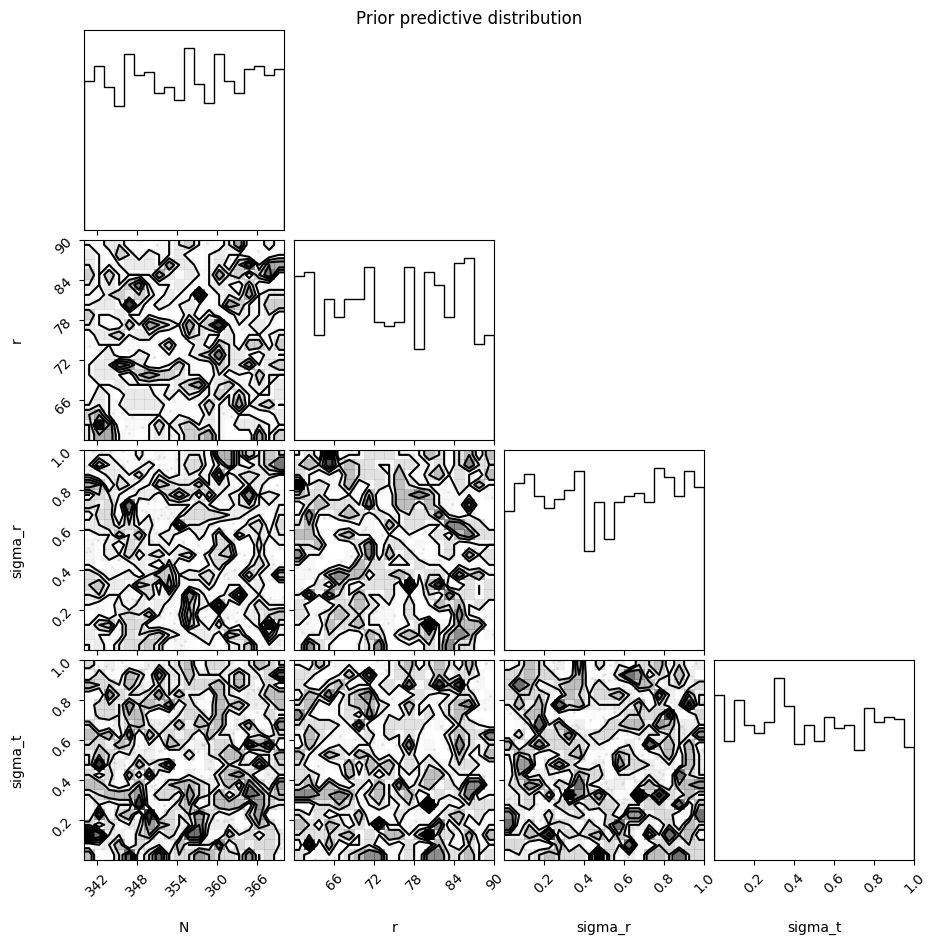

In [44]:
prior_samples_vis = az.from_dict(prior_samples_rt, num_chains=1)
fig = corner.corner(
    prior_samples_vis,
    var_names=["N", "r", "sigma_r", "sigma_t"],
    range=[(340, 370), (60, 90), (0, 1), (0, 1)],
)
fig.suptitle("Prior predictive distribution");

### Inference (Complex Model)

In [45]:
data_points = jnp.array(df[["Mean(X)", "Mean(Y)"]].to_numpy())

# MCMC Setup
nuts_kernel_rt = numpyro.infer.NUTS(model_rt)
mcmc_rt = numpyro.infer.MCMC(nuts_kernel_rt, num_warmup=5000, num_samples=10000)
key, subkey = jax.random.split(key) 
mcmc_rt.run(subkey, data = data_points)

# Summarize the MCMC results
mcmc_rt.print_summary()

sample: 100%|██████████| 15000/15000 [20:51<00:00, 11.99it/s, 1023 steps of size 2.10e-03. acc. prob=0.78]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         N    355.26      1.40    355.21    352.98    357.56    458.14      1.00
alpha_j[0]     34.97      0.57     34.98     34.00     35.81     26.32      1.00
alpha_j[1]     -8.81      0.00     -8.81     -8.81     -8.81    930.92      1.00
alpha_j[2]     60.31      0.00     60.31     60.30     60.31      2.06      1.00
alpha_j[3]     72.88      0.00     72.88     72.87     72.88    361.83      1.00
alpha_j[4]     92.04      0.74     92.09     90.97     93.17     15.10      1.15
alpha_j[5]    -27.68      0.02    -27.68    -27.70    -27.65   1903.86      1.00
alpha_j[6]    -84.22      0.03    -84.22    -84.27    -84.16   1259.23      1.00
alpha_j[7]    110.54      0.01    110.54    110.52    110.55    505.97      1.00
         r     77.34      0.29     77.33     76.88     77.82    416.19      1.00
   sigma_r      0.03      0.00      0.03      0.02      0.03   2643.15      1.00
   sigma_t      0.13      0

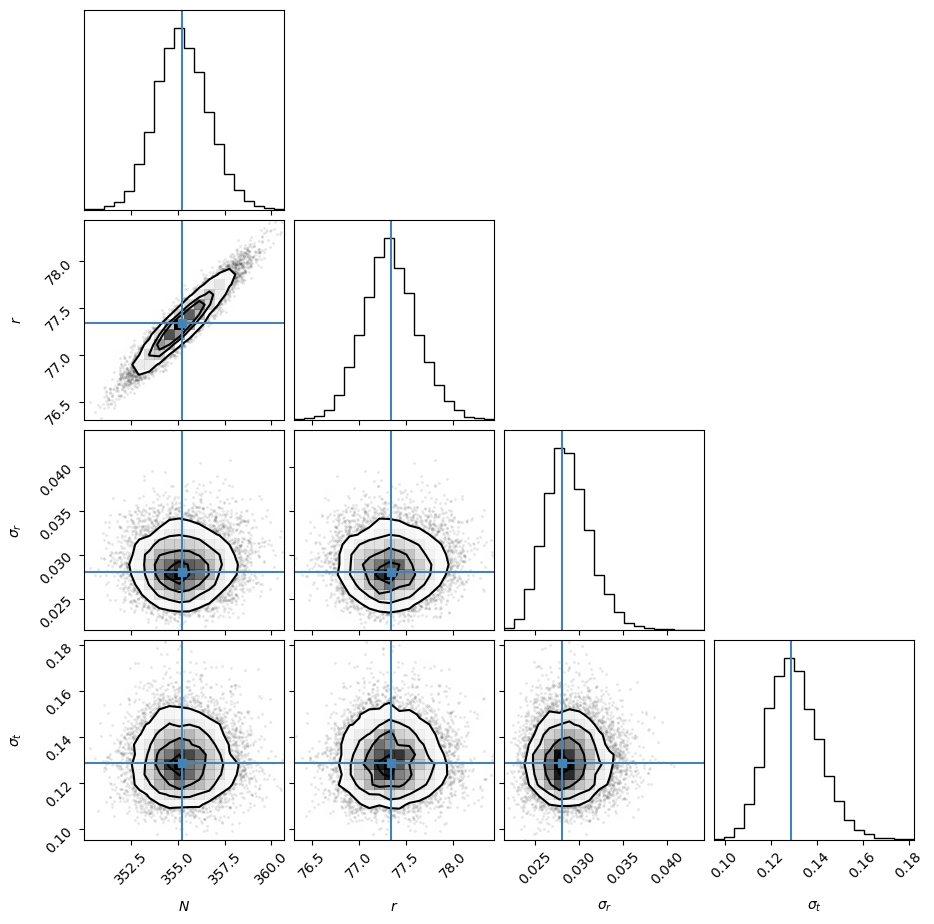

In [46]:
# Corner plot for the parameters
samples_rt = mcmc_rt.get_samples()

# Format data for arviz
samples_arviz_rt = {'N': np.array(samples_rt['N']),
    'r': np.array(samples_rt['r']),
    'sigma_r': np.array(samples_rt['sigma_r']),
    'sigma_t': np.array(samples_rt['sigma_t'])}

data_rt = az.from_dict(posterior=samples_arviz_rt)

true_params_rt = {"N": 355.24, "r": 77.34, "sigma_r": 0.028, "sigma_t": 0.129} # Our true parameters dictionary

labels_rt = [r'$N$', r'$r$', r'$\sigma_r$', r'$\sigma_t$']

figure_rt = corner.corner(data_rt, labels=labels_rt, truths=true_params_rt)

array([[<Axes: title={'center': 'N'}>, <Axes: title={'center': 'N'}>],
       [<Axes: title={'center': 'alpha_j'}>,
        <Axes: title={'center': 'alpha_j'}>],
       [<Axes: title={'center': 'r'}>, <Axes: title={'center': 'r'}>],
       [<Axes: title={'center': 'sigma_r'}>,
        <Axes: title={'center': 'sigma_r'}>],
       [<Axes: title={'center': 'sigma_t'}>,
        <Axes: title={'center': 'sigma_t'}>],
       [<Axes: title={'center': 'x_0j'}>,
        <Axes: title={'center': 'x_0j'}>],
       [<Axes: title={'center': 'y_0j'}>,
        <Axes: title={'center': 'y_0j'}>]], dtype=object)

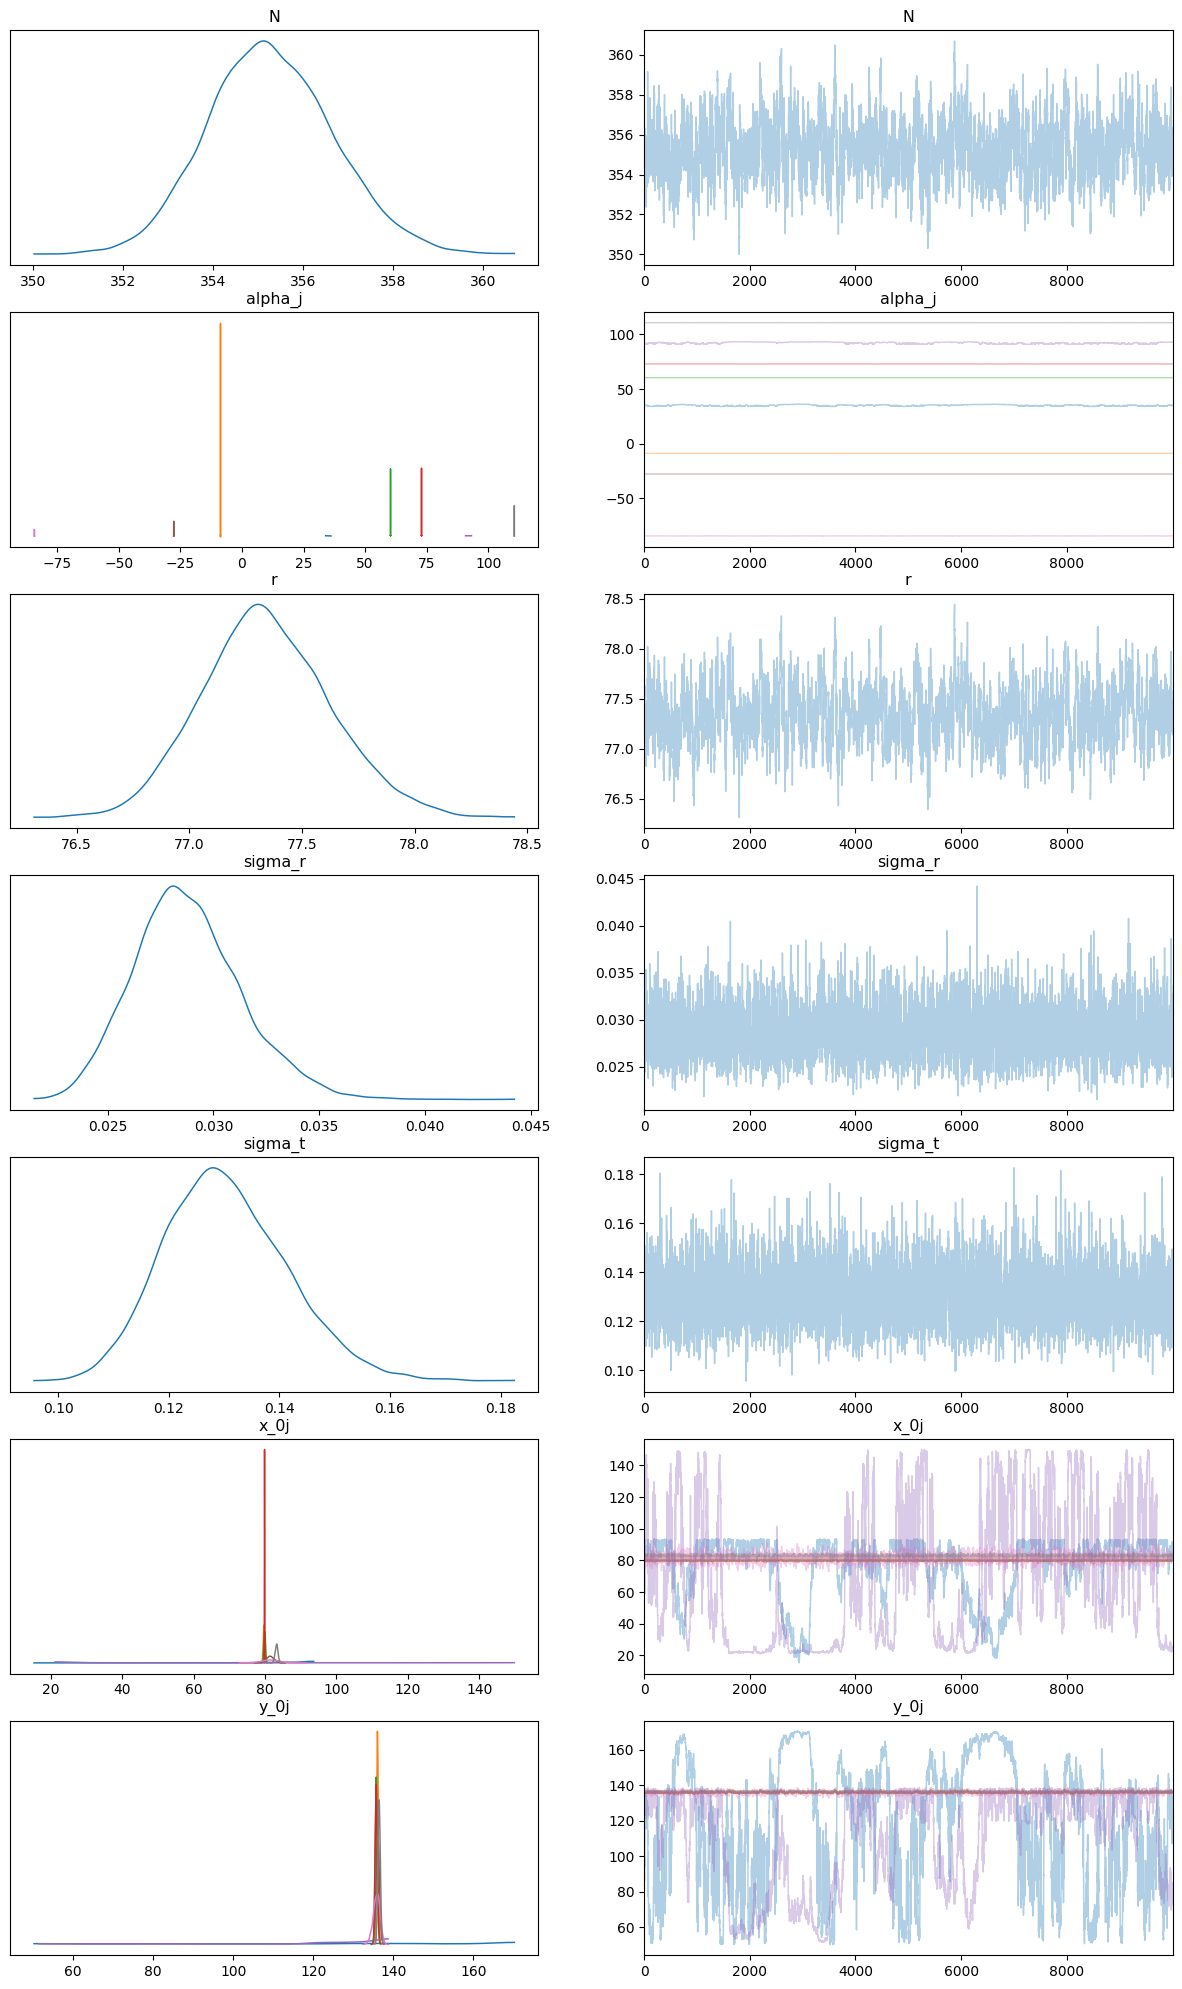

In [47]:
# Inspecting the learned parameters
data_rt = az.from_numpyro(mcmc_rt)
az.plot_trace(data_rt, compact=True, figsize=(15, 25))

### Posterior Predictive Distribution (Complex model)

[[[ 15.59931  92.59653]
  [ 16.44167  91.50069]
  [ 17.30764  90.34931]
  ...
  [111.14583  64.31736]
  [112.48021  64.82604]
  [113.64028  65.31528]]

 [[ 15.59931  92.59653]
  [ 16.44167  91.50069]
  [ 17.30764  90.34931]
  ...
  [111.14583  64.31736]
  [112.48021  64.82604]
  [113.64028  65.31528]]

 [[ 15.59931  92.59653]
  [ 16.44167  91.50069]
  [ 17.30764  90.34931]
  ...
  [111.14583  64.31736]
  [112.48021  64.82604]
  [113.64028  65.31528]]

 ...

 [[ 15.59931  92.59653]
  [ 16.44167  91.50069]
  [ 17.30764  90.34931]
  ...
  [111.14583  64.31736]
  [112.48021  64.82604]
  [113.64028  65.31528]]

 [[ 15.59931  92.59653]
  [ 16.44167  91.50069]
  [ 17.30764  90.34931]
  ...
  [111.14583  64.31736]
  [112.48021  64.82604]
  [113.64028  65.31528]]

 [[ 15.59931  92.59653]
  [ 16.44167  91.50069]
  [ 17.30764  90.34931]
  ...
  [111.14583  64.31736]
  [112.48021  64.82604]
  [113.64028  65.31528]]]


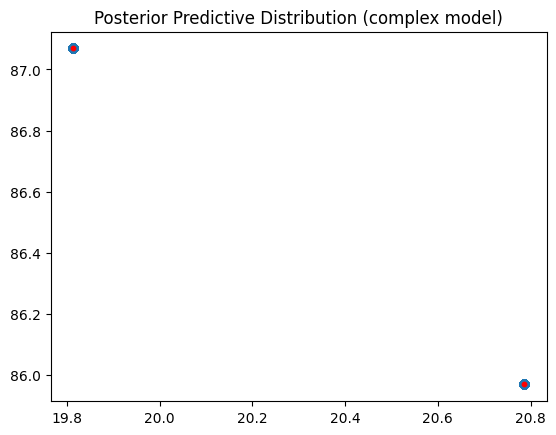

In [48]:
# Creating a posterior predictive distribution
predictive_rt_post = numpyro.infer.Predictive(model_rt, samples_rt)

# Generate random samples from the prior
data_points = jnp.array(df[["Mean(X)", "Mean(Y)"]].to_numpy())
predictions_rt_post = predictive_rt_post(rng_key=jax.random.PRNGKey(0), data=data_points)['obs']
print(predictions_rt_post)

# Visualizing posterior predictions
plt.scatter(predictions_rt_post[:,5:7,0], predictions_rt_post[:,5:7,1], alpha=0.5)
plt.scatter(df["Mean(X)"][5:7], df["Mean(Y)"][5:7], c='r', s=10)
plt.title("Posterior Predictive Distribution (complex model)")
plt.show()

### MLE parameters estimation

In [49]:
# defining the log likelihood function
def log_likelihood_rt(intended_positions, covariances, data_points):
    return numpyro.distributions.MultivariateNormal(loc=intended_positions, covariance_matrix=covariances).log_prob(data_points)

In [50]:
# defining negative log likelihood function
def neg_log_likelihood_rt(params, data_points):
    N = params[0]
    r = params[1]
    sigma_r = params[2]
    sigma_t = params[3]
    x_0j = params[4:12]
    y_0j = params[12:20]
    alpha_j = params[20:28]
    intended_positions, covariances = holes_locations_rt(N, r, sigma_r, sigma_t,
                            x_0j[0], x_0j[1], x_0j[2], x_0j[3], x_0j[4], x_0j[5], x_0j[6], x_0j[7],
                            y_0j[0], y_0j[1], y_0j[2], y_0j[3], y_0j[4], y_0j[5], y_0j[6], y_0j[7], 
                            alpha_j[0], alpha_j[1], alpha_j[2], alpha_j[3], alpha_j[4], alpha_j[5], alpha_j[6], alpha_j[7])
    return -jnp.sum(log_likelihood_rt(intended_positions, covariances, data_points))

data_points = jnp.array(df[["Mean(X)", "Mean(Y)"]].to_numpy())

#gradient calculation function
grad_neg_log_likelihood = jax.grad(neg_log_likelihood_rt)


In [51]:
# example of gradient calculation
neg_log_likelihood_rt(jnp.array([350, 70, 0.1, 0.1, 75,75,75,75,75,75,75,75,
                125,125,125,125,125,125,125,125, 0,0,0,0,0,0,0,0]), data_points)

Array(68517224., dtype=float32)

In [52]:
# define initial parameters
initial_params_rt = jnp.array([350, 70, 0.1, 0.1, 75,75,75,75,75,75,75,75,
                125,125,125,125,125,125,125,125, 0,0,0,0,0,0,0,0])

# Optimization
min_rt = opt.minimize(neg_log_likelihood_rt, initial_params_rt, args=(data_points), method='L-BFGS-B',
                    jac=jax.jit(jax.grad(neg_log_likelihood_rt)))

In [53]:
min_rt

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -175.9819793701172
        x: [ 3.421e+02  7.460e+01 ... -2.450e+00 -2.592e+00]
      nit: 991
      jac: [-2.690e+00 -5.839e-01 ...  6.103e+00  5.865e-01]
     nfev: 1127
     njev: 1127
 hess_inv: <28x28 LbfgsInvHessProduct with dtype=float64>

In [54]:
# Extracting and printing MLE parameters
mle_N_rt = min_rt.x[0]
mle_r_rt = min_rt.x[1]
mle_sigma_r_rt = min_rt.x[2]
mle_sigma_t_rt = min_rt.x[3]
mle_x_0j_rt = min_rt.x[4:12]
mle_y_0j_rt = min_rt.x[12:20]
mle_alpha_j_rt = min_rt.x[20:28]

print("MLE N:", mle_N_rt)
print("MLE r:", mle_r_rt)
print("MLE sigma r:", mle_sigma_r_rt)
print("MLE sigma t:", mle_sigma_t_rt)
print("MLE x_0j:", mle_x_0j_rt)
print("MLE y_0j:", mle_y_0j_rt)
print("MLE alpha_j:", mle_alpha_j_rt)

MLE N: 342.11408996308637
MLE r: 74.59897386537163
MLE sigma r: 0.054537583806238986
MLE sigma t: 0.1218683541325066
MLE x_0j: [81.0663425  77.77972176 77.55689814 79.62206575 72.8787915  73.82640257
 73.04568611 82.68962853]
MLE y_0j: [128.35823312 134.04579893 133.85710327 132.92680828 130.54702181
 130.66633645 129.46824687 133.26932527]
MLE alpha_j: [-2.62326357 -2.53287137 -2.52650899 -2.55568585 -2.46046047 -2.47246586
 -2.45041366 -2.59229464]


In [55]:
np.mean(mle_alpha_j_rt)

np.float64(-2.5267455507549723)

### Log Likelihood calculation (from samples)

In [56]:
# obtaining log likelihood
log_L_rt = numpyro.infer.log_likelihood(model_rt, samples_rt, data=data_points)

# calculating the log likelihood of all 81pts with given set of params
list_likelihoods_rt = np.zeros(len(log_L_rt['obs']))
for i in range (len(log_L_rt['obs'])):
    list_likelihoods_rt[i] = log_L_rt['obs'][i].sum()

# obtaining max log likelihood params
max_log_l_index_rt = np.argmax(list_likelihoods_rt)
max_logL_N_rt = samples_rt['N'][max_log_l_index_rt]
max_logL_r_rt = samples_rt['r'][max_log_l_index_rt]
max_logL_sigma_r_rt = samples_rt['sigma_r'][max_log_l_index_rt]
max_logL_sigma_t_rt = samples_rt['sigma_t'][max_log_l_index_rt]

Text(0.5, 0.98, 'Maximum Log Likelihood Parameters (complex)')

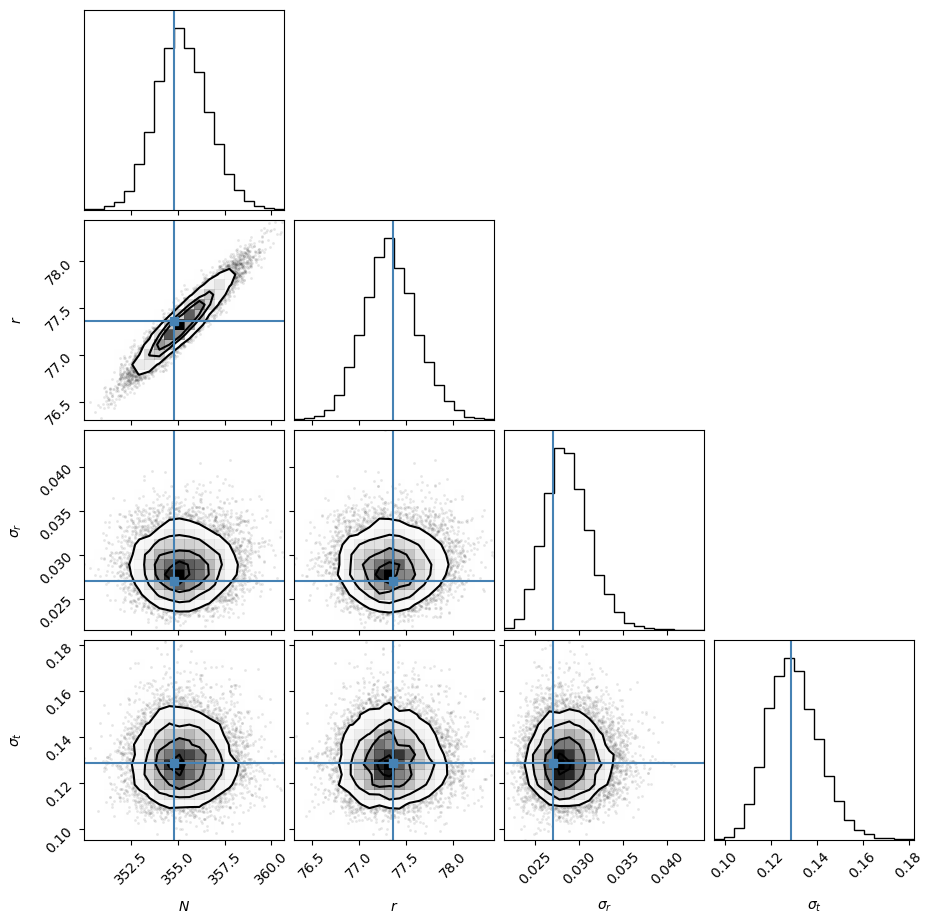

In [57]:
# Corner plot for the parameters
samples_rt = mcmc_rt.get_samples()

# Format data for arviz
samples_arviz_rt = {'N': np.array(samples_rt['N']),
    'r': np.array(samples_rt['r']),
    'sigma_r': np.array(samples_rt['sigma_r']),
    'sigma_t': np.array(samples_rt['sigma_t'])}

data_rt = az.from_dict(posterior=samples_arviz_rt)

labels_rt = [r'$N$', r'$r$', r'$\sigma_r$', r'$\sigma_t$']

figure = corner.corner(data_rt,labels=labels_rt, truths={"N": max_logL_N_rt, "r": max_logL_r_rt, "sigma_r": max_logL_sigma_r_rt, "sigma_t": max_logL_sigma_t_rt})

figure_rt.suptitle("Maximum Log Likelihood Parameters (complex)")

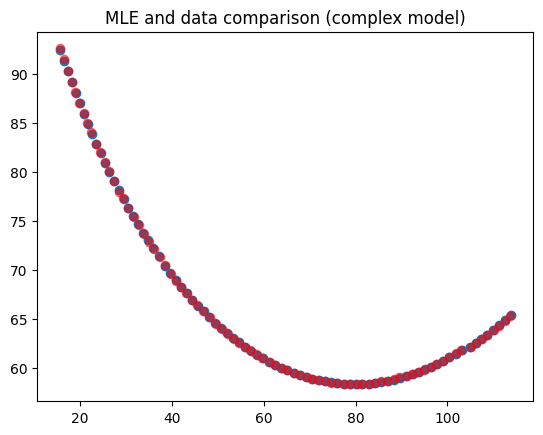

In [58]:
# max likelihood parameters plot
ML_data_test_rt = holes_locations(N=samples_rt['N'][max_log_l_index_rt], r=samples_rt['r'][max_log_l_index_rt], 
                            x_00=samples_rt['x_0j'][max_log_l_index_rt][0], x_01=samples_rt['x_0j'][max_log_l_index_rt][1], x_02=samples_rt['x_0j'][max_log_l_index_rt][2], x_03=samples_rt['x_0j'][max_log_l_index_rt][3], x_04=samples_rt['x_0j'][max_log_l_index_rt][4], x_05=samples_rt['x_0j'][max_log_l_index_rt][5], x_06=samples_rt['x_0j'][max_log_l_index_rt][6], x_07=samples_rt['x_0j'][max_log_l_index_rt][7],
                            y_00=samples_rt['y_0j'][max_log_l_index_rt][0], y_01=samples_rt['y_0j'][max_log_l_index_rt][1], y_02=samples_rt['y_0j'][max_log_l_index_rt][2], y_03=samples_rt['y_0j'][max_log_l_index_rt][3], y_04=samples_rt['y_0j'][max_log_l_index_rt][4], y_05=samples_rt['y_0j'][max_log_l_index_rt][5], y_06=samples_rt['y_0j'][max_log_l_index_rt][6], y_07=samples_rt['y_0j'][max_log_l_index_rt][7], 
                            alpha_0=samples_rt['alpha_j'][max_log_l_index_rt][0], alpha_1=samples_rt['alpha_j'][max_log_l_index_rt][1], alpha_2=samples_rt['alpha_j'][max_log_l_index_rt][2], alpha_3=samples_rt['alpha_j'][max_log_l_index_rt][3], alpha_4=samples_rt['alpha_j'][max_log_l_index_rt][4], alpha_5=samples_rt['alpha_j'][max_log_l_index_rt][5], alpha_6=samples_rt['alpha_j'][max_log_l_index_rt][6], alpha_7=samples_rt['alpha_j'][max_log_l_index_rt][7])

plt.scatter(ML_data_test_rt[:,0], ML_data_test_rt[:,1])
plt.scatter(df["Mean(X)"], df["Mean(Y)"], c='r', alpha=0.5)
plt.title("MLE and data comparison (complex model)")
plt.show()

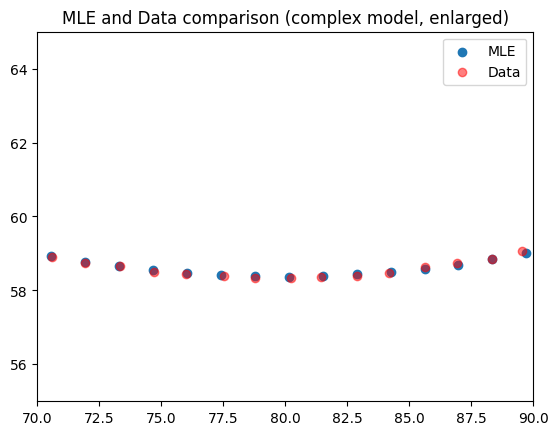

In [59]:
# max likelihood parameters plot
plt.scatter(ML_data_test_rt[:,0], ML_data_test_rt[:,1], label = 'MLE')
plt.scatter(df["Mean(X)"], df["Mean(Y)"], c='r', alpha=0.5, label = "Data")
plt.title("MLE and Data comparison (complex model, enlarged)")
plt.xlim(70,90)
plt.ylim(55,65)
plt.legend()
plt.show()

#### logL Derivative Calculation (from samples)

In [60]:
# Function to compute log-likelihood
def log_likelihood_fn_rt(N, r, sigma_r, sigma_t, alpha_j, x_0j, y_0j, data):
    s = 8  # Number of sections
    num_points = 81
    cov = jnp.array([[sigma_r**2, 0], [0, sigma_t**2]])

    model_ll_rt = numpyro.deterministic("model_ll_rt", holes_locations(N, r, 
                            x_0j[0], x_0j[1], x_0j[2], x_0j[3], x_0j[4], x_0j[5], x_0j[6], x_0j[7],
                            y_0j[0], y_0j[1], y_0j[2], y_0j[3], y_0j[4], y_0j[5], y_0j[6], y_0j[7], 
                            alpha_j[0], alpha_j[1], alpha_j[2], alpha_j[3], alpha_j[4], alpha_j[5], alpha_j[6], alpha_j[7]))
        
    with numpyro.plate("data", num_points):
        distr =  numpyro.distributions.MultivariateNormal(model_ll_rt, covariance_matrix=cov)
    
    log_prob = distr.log_prob(data) 
    return jnp.sum(log_prob)

N_maxL_rt = samples_rt['N'][max_log_l_index_rt]
r_maxL_rt = samples_rt['r'][max_log_l_index_rt]
sigma_r_maxL_rt = samples_rt['sigma_r'][max_log_l_index_rt]
sigma_t_maxL_rt = samples_rt['sigma_t'][max_log_l_index_rt]
alpha_j_maxL_rt = samples_rt['alpha_j'][max_log_l_index_rt]
x_0j_maxL_rt = samples_rt['x_0j'][max_log_l_index_rt]
y_0j_maxL_rt = samples_rt['y_0j'][max_log_l_index_rt]

# Calculate log-likelihood using the parameter samples
log_L = log_likelihood_fn_rt(N_maxL_rt, r_maxL_rt, sigma_r_maxL_rt, sigma_t_maxL_rt, 
                            alpha_j_maxL_rt, x_0j_maxL_rt, y_0j_maxL_rt, data_points)

# Calculate gradients if necessary
grad_log_L = jax.grad(log_likelihood_fn_rt)(N_maxL_rt, r_maxL_rt, sigma_r_maxL_rt, sigma_t_maxL_rt, 
                                        alpha_j_maxL_rt, x_0j_maxL_rt, y_0j_maxL_rt, data_points)

# Output results
print("Log-Likelihood:", log_L)
print("Gradient of Log-Likelihood:", grad_log_L)

Log-Likelihood: -345.70746
Gradient of Log-Likelihood: 183.393


In [61]:
for i in range(0, 100): #1000 used here as well
    N_sample_rt = samples_rt['N'][i]
    r_sample_rt = samples_rt['r'][i]
    sigma_r_sample_rt = samples_rt['sigma_r'][i]
    sigma_t_sample_rt = samples_rt['sigma_t'][i]
    alpha_j_sample_rt = samples_rt['alpha_j'][i]
    x_0j_sample_rt = samples_rt['x_0j'][i]
    y_0j_sample_rt = samples_rt['y_0j'][i]

    # Calculate log-likelihood using the parameter samples
    log_L_rt = log_likelihood_fn_rt(N_sample_rt, r_sample_rt, sigma_r_sample_rt, sigma_t_sample_rt,
                            alpha_j_sample_rt, x_0j_sample_rt, y_0j_sample_rt, data_points)

    # Calculate gradients if necessary
    grad_log_L_rt = jax.grad(log_likelihood_fn_rt)(N_sample_rt, r_sample_rt, sigma_r_sample_rt, sigma_t_sample_rt, 
                                        alpha_j_sample_rt, x_0j_sample_rt, y_0j_sample_rt, data_points)

    if (np.isclose(grad_log_L_rt, 0, rtol = 1e-2, atol = 1e-2)):
        print("Index:", i)
    # Output results
    #print("Log-Likelihood:", log_L)
    #print("Gradient of Log-Likelihood:", grad_log_L)

In [62]:
print("N from grad:", N_sample_rt, ", from max(log_likelihood):", N_maxL_rt)
print("r from grad:", r_sample_rt, ", from max(log_likelihood):", r_maxL_rt)
print("sigma_r from grad:", sigma_r_sample_rt, ", from max(log_likelihood):", sigma_r_maxL_rt)
print("sigma_t from grad:", sigma_t_sample_rt, ", from max(log_likelihood):", sigma_t_maxL_rt)

N from grad: 357.13528 , from max(log_likelihood): 354.79538
r from grad: 77.68083 , from max(log_likelihood): 77.36686
sigma_r from grad: 0.02819016 , from max(log_likelihood): 0.02699537
sigma_t from grad: 0.14753789 , from max(log_likelihood): 0.12872738


### MLE both models vs Data

In [63]:
MLE_test_rt, covs = holes_locations_rt(N=mle_N_rt, r=mle_r_rt, sigma_r=mle_sigma_r_rt, sigma_t=mle_sigma_t_rt,
                            x_00=mle_x_0j_rt[0], x_01=mle_x_0j_rt[1], x_02=mle_x_0j_rt[2], x_03=mle_x_0j_rt[3], x_04=mle_x_0j_rt[4], x_05=mle_x_0j_rt[5], x_06=mle_x_0j_rt[6], x_07=mle_x_0j_rt[7],
                            y_00=mle_y_0j_rt[0], y_01=mle_y_0j_rt[1], y_02=mle_y_0j_rt[2], y_03=mle_y_0j_rt[3], y_04=mle_y_0j_rt[4], y_05=mle_y_0j_rt[5], y_06=mle_y_0j_rt[6], y_07=mle_y_0j_rt[7], 
                            alpha_0=mle_alpha_j_rt[0], alpha_1=mle_alpha_j_rt[1], alpha_2=mle_alpha_j_rt[2], alpha_3=mle_alpha_j_rt[3], alpha_4=mle_alpha_j_rt[4], alpha_5=mle_alpha_j_rt[5], alpha_6=mle_alpha_j_rt[6], alpha_7=mle_alpha_j_rt[7])


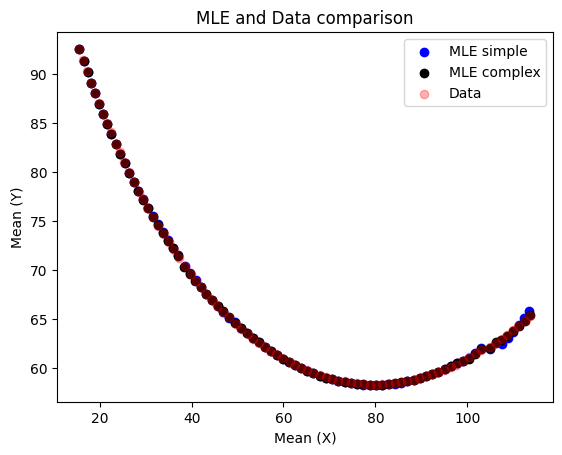

In [64]:
# max likelihood parameters plot
plt.scatter(MLE_test[:,0], MLE_test[:,1], c='blue', label = 'MLE simple')
plt.scatter(MLE_test_rt[:,0], MLE_test_rt[:,1], c='black', label = 'MLE complex')
plt.scatter(df["Mean(X)"], df["Mean(Y)"], c='red', alpha=0.3, label = "Data")
plt.title("MLE and Data comparison")
plt.xlabel("Mean (X)")
plt.ylabel("Mean (Y)")
plt.legend()
plt.show()

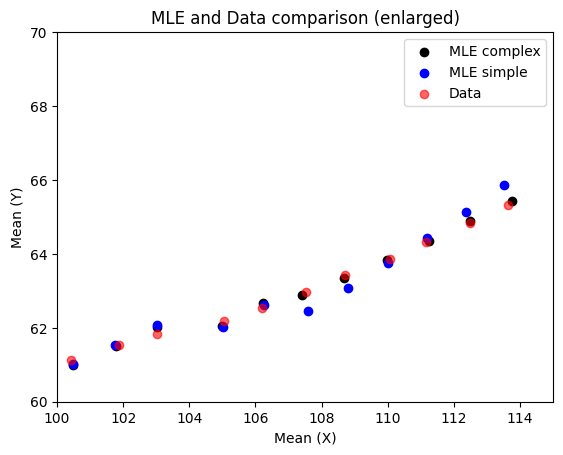

In [65]:
# max likelihood parameters plot, enlarged
plt.scatter(MLE_test_rt[:,0], MLE_test_rt[:,1], c='black', label = 'MLE complex')
plt.scatter(MLE_test[:,0], MLE_test[:,1], c='b', label = 'MLE simple')
plt.scatter(df["Mean(X)"], df["Mean(Y)"], c='r', alpha=0.6, label = "Data")
plt.title("MLE and Data comparison (enlarged)")
plt.xlim(100,115)
plt.ylim(60,70)
plt.xlabel("Mean (X)")
plt.ylabel("Mean (Y)")
plt.legend()
plt.show()

## Model Comparison

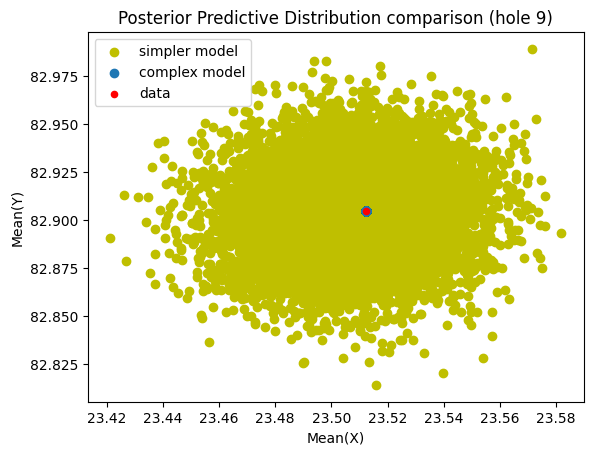

In [66]:
# posterior predictive distributions on one point, number 9
point_number = 9
plt.scatter(predictions[:,point_number,0], predictions[:,point_number,1], c='y', label = "simpler model")
plt.scatter(predictions_rt_post[:,point_number,0], predictions_rt_post[:,point_number,1], label = "complex model")
plt.scatter(df["Mean(X)"][point_number], df["Mean(Y)"][point_number], c='r', label = "data", s=20)
plt.title("Posterior Predictive Distribution comparison (hole 9)")
plt.xlabel("Mean(X)")
plt.ylabel("Mean(Y)")
#plt.xlim(66,68)
#plt.ylim(59,59.75)
plt.legend()
plt.show()

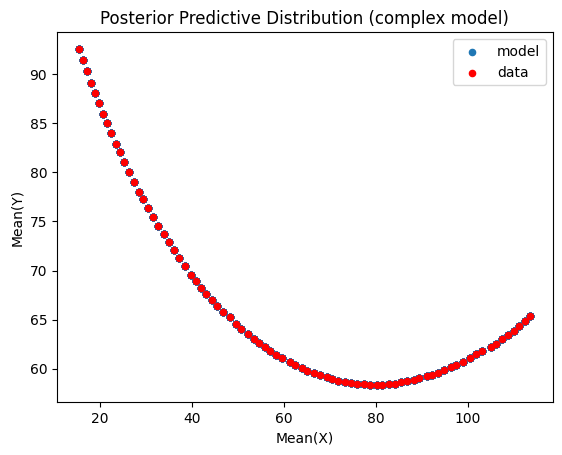

In [67]:
# posterior predictive distributions
#plt.scatter(predictions[:,:,0], predictions[:,:,1], c='y', label = "simpler model")
plt.scatter(predictions_rt_post[:,:,0], predictions_rt_post[:,:,1], label = "model", s=20)
plt.scatter(df["Mean(X)"], df["Mean(Y)"], c='r', label = "data", s=20)
plt.title("Posterior Predictive Distribution (complex model)")
plt.xlabel("Mean(X)")
plt.ylabel("Mean(Y)")
#plt.xlim(66,68)
#plt.ylim(59,59.75)
plt.legend()
plt.show()

The evidence ratio acts to update our prior odds ratio and gives us the posterior odds ratio. In this case, the model with only one sigma is nested inside the radial+tangential sigmas model (with $\sigma_t=\sigma_r$) and therefore the Savage-Dickey ratio can be used to estimate the evidence ratio. 

From the above posteriors, it can be seen that the posterior $P(c|\boldsymbol{y})$ is peaked away from $\sigma_t=\sigma_r$, indicating that the data favours the more complicated model.

In [68]:
from scipy.stats import gaussian_kde

# calculating posterior density for more complex model
sigma_r_samples = mcmc_rt.get_samples()['sigma_r']
sigma_t_samples = mcmc_rt.get_samples()['sigma_t']
samples_rt = np.vstack([sigma_r_samples, sigma_t_samples]) #stack for gaussian_kde

# posterior density for simpler model
sigma_samples = mcmc.get_samples()['sigma']
kde = gaussian_kde(sigma_samples)
sigma_value = sigma_samples.mean()
density = kde(sigma_value)

kde_rt = gaussian_kde(samples_rt) # create a kernel density estimator object
density_rt = kde_rt([sigma_value, sigma_value]) # how probable is this value for the radial-tangential model

# calculate Savage-Dickey ratio
sd_ratio = density_rt / density
print("Savage-Dickey Ratio:", sd_ratio)

Savage-Dickey Ratio: [0.]


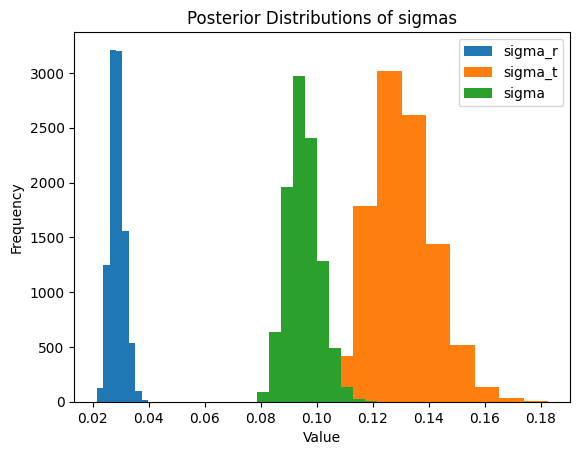

In [69]:
# Plot the distributions for sigmas
plt.hist(sigma_r_samples, label='sigma_r')
plt.hist(sigma_t_samples, label='sigma_t')
plt.hist(sigma_samples, label='sigma')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Posterior Distributions of sigmas")
plt.legend()
plt.show()

In [70]:
from scipy.stats import norm
# estimating the distance in standard deviations
sigma_r_mean = sigma_r_samples.mean()
sigma_t_mean = sigma_t_samples.mean()
sigma_r_std = sigma_r_samples.std()
sigma_t_std = sigma_t_samples.std()

# Calculate the number of standard deviations away from the mean
distance_r = abs(sigma_value - sigma_r_mean) / sigma_r_std
distance_t = abs(sigma_value - sigma_t_mean) / sigma_t_std
print(distance_r)
print(distance_t)

# we take the minimum distance, as calculating the upper bound
distance = np.minimum(distance_r, distance_t)

# Calculate the density of a standard normal distribution at that number of standard deviations away
density_at_distance = norm.pdf(distance)

# upper bound on the Savage-Dickey ratio
upper_bound = density_at_distance / density

print("A very safe Upper Bound on Savage-Dickey ratio:", upper_bound)

26.164783
3.1334946
A very safe Upper Bound on Savage-Dickey ratio: [4.21999205e-05]


## Below is related, but unnecessary code.
It was used in the process of achieving the goal and is stored here just in case. Mainly includes simplified or trial versions of functions used above in the main part.

In [71]:
# # defining the model that outputs coordinates of 81 pts, given center location
# def holes_locations_trial(N, r, x_0j, y_0j, alpha_j, s=8, num_holes=81):
#     intended_positions = jnp.zeros((num_holes, 2))

#     for i in range(num_holes):
#         phi_ij = 2 * jnp.pi * (i - 1) / N + alpha_j # angular position of the ith hole in the jth section with respect to its arc-centre
#         r_ij = jnp.array([jnp.cos(phi_ij), jnp.sin(phi_ij)]) * r  #distance from jth centre 
#         intended_pos_ij = r_ij + jnp.array([x_0j, y_0j]) # Intended hole position
#         intended_positions = intended_positions.at[i].set(intended_pos_ij)

#     return intended_positions

In [72]:
# # mock data production
# mock_data_trial = holes_locations_trial(N=355, r=77, x_0j=80, y_0j=135, alpha_j=-146)
# plt.scatter(mock_data_trial[:,0], mock_data_trial[:,1])

In [73]:
# # model with a 2-dimensional isotropic Gaussian distribution with standard deviation sigma
# def model1(data):
#     s = 8 # Number of sections
    
#     # Defining priors
#     N = numpyro.sample("N", numpyro.distributions.Uniform(346., 368.)) 
#     r = numpyro.sample("r", numpyro.distributions.Uniform(0., 100.))
#     sigma = numpyro.sample("sigma", numpyro.distributions.LogNormal(-4.0, 0.5))

#     cov = jnp.array([[sigma**2, 0], [0, sigma**2]])

#     for j in range(s):
#         alpha_j = numpyro.sample(f"alpha_{j}", numpyro.distributions.Uniform(-200., 100.)) # angular position of the first hole
#         x_0j = numpyro.sample(f"x_0{j}", numpyro.distributions.Uniform(50., 100.))
#         y_0j = numpyro.sample(f"y_0{j}", numpyro.distributions.Uniform(100., 150.))

#         model = numpyro.deterministic(f"model_{j}", holes_locations_trial(N,r,x_0j,y_0j,alpha_j))
        
#         with numpyro.plate("data", len(data)):
#             numpyro.sample(f"obs{j}", numpyro.distributions.MultivariateNormal(model, covariance_matrix = cov), obs=data)

In [74]:
# data_points = jnp.array(df[["Mean(X)", "Mean(Y)"]].to_numpy())

# # MCMC Setup
# nuts_kernel1 = numpyro.infer.NUTS(model1)
# mcmc1 = numpyro.infer.MCMC(nuts_kernel1, num_warmup=1000, num_samples=5000)
# key, subkey = jax.random.split(key) 
# mcmc1.run(subkey, data = data_points)

# # Summarize the MCMC results
# mcmc1.print_summary()

In [75]:
# # Corner plot for the parameters
# samples1 = mcmc1.get_samples()

# labels1 = [r'$N$', r'$r$', r'$\sigma$']
# corner.corner(np.array(jnp.vstack((samples1['N'], samples1['r'], samples1['sigma'])).T),labels=labels1)
# plt.show()